# Federated Learning with Flower: Healthcare Data Analysis

## 📋 Overview

This notebook implements a **Federated Learning** system using the Flower framework to train a Logistic Regression model across multiple healthcare clients without sharing their raw data.

### 🎯 Key Objectives:
1. Train a machine learning model across 4 distributed healthcare clients (P, L, H, Br)
2. Keep all data private and local to each client
3. Aggregate model parameters using FedAvg (Federated Averaging)
4. Evaluate the global model's performance
5. Identify the most important features for outcome prediction

### 📊 Dataset:
- **Target Variable**: `outcome_predict1(2p-2mm_bin)` (binary classification)
- **Clients**: 4 healthcare institutions with their own patient data
- **Features**: Numeric clinical measurements (automatically selected)

## 📂 Step 1: Upload Data Files

Upload the four Excel files containing patient data from each healthcare client:
- `client_P Total Composite 6.16.23.xlsx`
- `client_L Total Composite 6.16.23.xlsx`
- `client_H Total Composite 6.16.23.xlsx`
- `client_Br Total Composite 6.16.23.xlsx`

**Expected Output**: File upload interface will appear, allowing you to select and upload the files.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving client_Br Total Composite 6.16.23.xlsx to client_Br Total Composite 6.16.23.xlsx
Saving client_H Total Composite 6.16.23.xlsx to client_H Total Composite 6.16.23.xlsx
Saving client_L Total Composite 6.16.23.xlsx to client_L Total Composite 6.16.23.xlsx
Saving client_P Total Composite 6.16.23.xlsx to client_P Total Composite 6.16.23.xlsx


In [2]:
uploaded.keys()

dict_keys(['client_Br Total Composite 6.16.23.xlsx', 'client_H Total Composite 6.16.23.xlsx', 'client_L Total Composite 6.16.23.xlsx', 'client_P Total Composite 6.16.23.xlsx'])

### Verify Uploaded Files

Check which files were successfully uploaded.

**Expected Output**: Dictionary keys showing the names of uploaded files.

## 🔧 Step 2: Install Required Libraries

Install the Flower framework with simulation support. This includes:
- **Flower**: Federated learning framework
- **Ray**: Distributed computing backend for simulation
- **gRPC**: Communication protocol

**Expected Output**: Installation progress and confirmation messages.

In [3]:
!pip install -U "flwr[simulation]"

INFO: pip is looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install flwr

### Additional Flower Installation

Ensures Flower core library is installed (backup installation).

**Expected Output**: "Requirement already satisfied" or installation confirmation.

## 📦 Step 3: Import Libraries

Import all necessary libraries for:
- **Data Processing**: pandas, numpy
- **Machine Learning**: scikit-learn (Logistic Regression, preprocessing, metrics)
- **Federated Learning**: Flower framework
- **Type Hints**: typing module for better code documentation

The warnings are suppressed to keep output clean.

**Expected Output**: No output (silent import).

In [5]:
import pandas as pd
import numpy as np
import os
import flwr as fl
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from typing import Dict, Tuple, List, Optional, Callable
# Optional if certain warning appear
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [6]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## ⚙️ Step 4: Configuration - Define Target Variable

Set the target column for prediction. This is the outcome we want to predict across all clients.

**Variable**: `outcome_predict1(2p-2mm_bin)` - Binary classification target (0 or 1)

**Expected Output**: No output (variable definition).

### Configuration - Map Client IDs to Data Files

**Critical Configuration**: Maps numeric client IDs (assigned by Flower) to actual data files.

- **'0'** → client_P (Healthcare institution P)
- **'1'** → client_L (Healthcare institution L)
- **'2'** → client_H (Healthcare institution H)
- **'3'** → client_Br (Healthcare institution Br)

⚠️ **Important**: Flower assigns numeric IDs ('0', '1', '2', '3') during simulation, so we must use these as keys.

**Expected Output**: No output (dictionary definition).

In [7]:
TARGET_COL = 'outcome_predict1(2p-2mm_bin)'

In [8]:
# CRITICAL FIX: Use numeric string keys ('0', '1', '2', '3') to match Flower's client IDs
DATA_FILES = {
    '0': "client_P Total Composite 6.16.23.xlsx",
    '1': "client_L Total Composite 6.16.23.xlsx",
    '2': "client_H Total Composite 6.16.23.xlsx",
    '3': "client_Br Total Composite 6.16.23.xlsx"
}

### Configuration - Display Names for Clients

Maps numeric IDs to human-readable names for better output visualization.

**Expected Output**: No output (dictionary definition).

### Configuration - Global Variable for Final Parameters

Initialize a global variable to store the final aggregated model parameters after federated training completes.

**Expected Output**: No output (variable initialization).

In [9]:
# Mapping for display names
CLIENT_NAMES = {
    '0': 'client_P',
    '1': 'client_L',
    '2': 'client_H',
    '3': 'client_Br'
}

In [10]:
# Variable to hold the final parameters
final_aggregated_parameters: Optional[List[np.ndarray]] = None

## 🔄 Step 5: Data Preprocessing Function

This function handles all data loading and preprocessing for each client:

### Operations Performed:
1. **Load Excel file** - Reads client's data file
2. **Clean column names** - Removes extra whitespace
3. **Feature selection** - Automatically selects numeric columns, excludes IDs and outcome columns
4. **Handle missing values** - Fills missing values with column mean
5. **Standardization** - Scales features using StandardScaler (zero mean, unit variance)
6. **Train/Validation split** - 80/20 split with stratification

### Returns:
- Training features (X_train)
- Validation features (X_val)
- Training labels (y_train)
- Validation labels (y_val)
- Feature names list

**Expected Output**: No output (function definition).

In [11]:
# --- 2. DATA UTILITY FUNCTIONS ---
def load_and_preprocess_data(file_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """Loads, preprocesses, and splits client data."""
    if file_path is None or not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found at path: {file_path}")

    df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip()

    excluded_cols = ['PID', TARGET_COL, 'outcome_predict2(T218_90%_bin)', 'outcome_predict2(T218)', 'outcome_predict1(2p-2mm)']
    feature_cols = [col for col in df.columns if col not in excluded_cols and np.issubdtype(df[col].dtype, np.number)]

    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())

    X = df[feature_cols]
    y = df[TARGET_COL]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
    )

    return X_train.values, X_val.values, y_train.values, y_val.values, feature_cols


## 🤖 Step 6: Flower Client Implementation

Defines the federated learning client class that represents each healthcare institution.

### Key Components:

#### `__init__(self, cid)`:
- Loads and preprocesses local data
- Initializes Logistic Regression model
- Sets binary classes [0, 1]

#### `get_parameters(config)`:
- Extracts model coefficients and intercept
- Returns model parameters as numpy arrays

#### `set_parameters(parameters)`:
- Updates local model with global parameters from server

#### `fit(parameters, config)`:
- Receives global parameters
- Trains model on local training data
- Returns updated parameters and training set size

#### `evaluate(parameters, config)`:
- Evaluates model on local validation data
- Returns loss, validation set size, and accuracy

### How it Works:
Each client trains locally on their private data and only shares model parameters (not data) with the central server.

**Expected Output**: No output (class definition).

In [12]:
# --- 3. FLOWER CLIENT IMPLEMENTATION ---
class FlowerLogisticRegressionClient(fl.client.NumPyClient):

    def __init__(self, cid: str):
        self.cid = cid
        self.file_path = DATA_FILES.get(cid)

        if self.file_path is None:
            raise ValueError(f"Flower Client Error: Client ID '{cid}' not found in DATA_FILES mapping. Available IDs: {list(DATA_FILES.keys())}")

        X_train, X_val, y_train, y_val, feature_names = load_and_preprocess_data(self.file_path)

        self.X_train, self.y_train = X_train, y_train
        self.X_val, self.y_val = X_val, y_val
        self.feature_names = feature_names

        self.model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
        self.model.classes_ = np.array([0, 1])

    def get_parameters(self, config):
        if not hasattr(self.model, "coef_"):
            n_features = self.X_train.shape[1]
            self.model.coef_ = np.zeros((1, n_features))
            self.model.intercept_ = np.zeros(1)
        return [self.model.coef_, self.model.intercept_]

    def set_parameters(self, parameters):
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1]

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.fit(self.X_train, self.y_train)
        return self.get_parameters(config={}), len(self.X_train), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        y_pred = self.model.predict(self.X_val)
        y_proba = self.model.predict_proba(self.X_val)
        loss = log_loss(self.y_val, y_proba)
        acc = accuracy_score(self.y_val, y_pred)
        return float(loss), len(self.X_val), {"accuracy": float(acc)}


## 🔧 Step 7: Utility Functions for Flower

These helper functions configure the federated learning process:

### `client_fn(cid)`:
- **Factory function** that creates a Flower client for a given client ID
- Converts NumPyClient to standard Flower Client interface

### `get_on_fit_config_fn()`:
- Returns a function that provides training configuration
- Currently returns empty config (can be extended for hyperparameters)

### `get_on_evaluate_config_fn()`:
- Returns a function that provides evaluation configuration
- Used for customizing evaluation behavior per round

**Expected Output**: No output (function definitions).

In [13]:
# --- 4. FLOWER UTILITY FUNCTIONS (For Strategy and Client Creation) ---

def client_fn(cid: str) -> fl.client.Client:
    """Factory to create a Flower client per client ID."""
    return FlowerLogisticRegressionClient(cid).to_client()

def get_on_fit_config_fn() -> Callable:
    """Returns a function that provides training configuration."""
    def fit_config(server_round: int):
        return {}
    return fit_config

def get_on_evaluate_config_fn() -> Callable:
    """Returns a function that provides evaluation configuration."""
    def evaluate_config(server_round: int):
        return {}
    return evaluate_config


## 📊 Step 8: Custom Federated Averaging Strategy

Extends Flower's `FedAvg` strategy to save final aggregated parameters.

### How Federated Averaging Works:
1. **Server** sends global model parameters to selected clients
2. **Clients** train locally on their data
3. **Clients** send updated parameters back to server
4. **Server** aggregates parameters using weighted average (based on training set sizes)
5. Process repeats for multiple rounds

### Custom Feature:
The `aggregate_fit` method is overridden to:
- Call parent class aggregation
- **Save final parameters** after round 5
- Store parameters globally for later evaluation

**Expected Output**: No output (class definition).

In [14]:
# Custom strategy to capture final parameters
class SaveParamsFedAvg(fl.server.strategy.FedAvg):
    """Custom FedAvg strategy that saves final aggregated parameters."""

    def aggregate_fit(self, server_round, results, failures):
        """Aggregate fit results and save parameters from final round."""
        global final_aggregated_parameters

        # Call parent class method to perform aggregation
        aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)

        # Save parameters from the final round
        if server_round == 5 and aggregated_parameters is not None:
            from flwr.common import parameters_to_ndarrays
            final_aggregated_parameters = parameters_to_ndarrays(aggregated_parameters)

        return aggregated_parameters, aggregated_metrics

## 🚀 Step 9: Main Federated Learning Function

This is the core function that orchestrates the entire federated learning process.

### Process Flow:

#### 1. **Data Pre-Check** (Lines 1-14):
- Validates all client data files exist
- Loads feature names
- Confirms each client's data is accessible

#### 2. **Strategy Configuration** (Lines 16-23):
- Creates custom FedAvg strategy
- Sets all clients to participate (fraction_fit=1.0)
- Requires all 4 clients for training and evaluation

#### 3. **Simulation Execution** (Lines 25-32):
- Runs Flower simulation with Ray backend
- Executes 5 rounds of federated learning
- Each round: clients train → server aggregates → repeat

#### 4. **Feature Importance Analysis** (Lines 34-50):
- Extracts final aggregated coefficients
- Ranks features by absolute weight (importance)
- Displays top 10 most influential features
- Shows positive/negative direction of influence

### Expected Output:
- ✅ Pre-check confirmations for each client
- 🚀 Simulation start message
- Round-by-round training progress
- ✅ Completion confirmation
- 🏆 Top 10 feature importance table

**Expected Output**: Detailed training logs and feature importance ranking.

In [15]:
# --- 5. MAIN FEDERATED TRAINING LOOP ---

def main():
    global final_aggregated_parameters

    # Data File Pre-Check
    feature_names = None
    print("--- Running Data Pre-Check ---")
    for cid, file_path in DATA_FILES.items():
        try:
            _, _, _, _, current_feature_names = load_and_preprocess_data(file_path)
            if feature_names is None:
                feature_names = current_feature_names
            client_name = CLIENT_NAMES.get(cid, cid)
            print(f" Initial load check passed for: {client_name} (ID: {cid})")
        except FileNotFoundError as e:
            print(f" CRITICAL ERROR: {e}")
            print("Please upload all Excel files and try again.")
            return
    print("------------------------------")

    num_clients = len(DATA_FILES)

    # Use the custom strategy class
    strategy = SaveParamsFedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=num_clients,
        min_evaluate_clients=num_clients,
        min_available_clients=num_clients,
        on_fit_config_fn=get_on_fit_config_fn(),
        on_evaluate_config_fn=get_on_evaluate_config_fn(),
    )

    print("🚀 Starting Flower Federated Learning Simulation...")
    history = fl.simulation.start_simulation(
        client_fn=client_fn,
        config=fl.server.ServerConfig(num_rounds=5),
        strategy=strategy,
        num_clients=num_clients,
        ray_init_args={"ignore_reinit_error": True},
    )

    print("\n Simulation completed successfully.")

    # --- RESULTS: Feature Importance ---

    if final_aggregated_parameters is not None and feature_names is not None:
        print("\n\n--- RESULTS: Feature Importance ---")

        # final_aggregated_parameters is a list: [coef_, intercept_]
        aggregated_coefs = final_aggregated_parameters[0][0]  # Get coefficients (first element, first row)

        # Create a list of tuples: (feature_name, coefficient)
        feature_weights = list(zip(feature_names, aggregated_coefs))

        # Sort by absolute value of the coefficient (importance)
        feature_weights.sort(key=lambda x: abs(x[1]), reverse=True)

        print("\n Top 10 Features (by absolute weight):")
        print("| Rank | Feature                   | Importance | Direction |")
        print("|------|---------------------------|------------|-----------|")
        for i, (feature, weight) in enumerate(feature_weights[:10]):
            score = abs(weight)
            direction = "Positive" if weight > 0 else "Negative"
            print(f"| {i+1:<4} | {feature:<25} | {score:^10.4f} | {direction:<9} |")
    else:
        print("\n Could not extract final parameters or feature names.")

## 📈 Step 10: Evaluation Function - Aggregated Model Performance

This function evaluates the final federated model's performance on each client's validation set.

### Evaluation Process:

#### 1. **Model Reconstruction** (Lines 12-18):
- Creates a Logistic Regression model
- Sets aggregated coefficients and intercept from federated training
- This is the **global model** trained across all clients

#### 2. **Per-Client Evaluation** (Lines 20-50):
For each client, calculates:
- **Accuracy**: Percentage of correct predictions
- **Loss**: Log loss (cross-entropy)
- **Precision**: True Positives / (True Positives + False Positives)
- **Recall**: True Positives / (True Positives + False Negatives)
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: TN, FP, FN, TP breakdown

#### 3. **Overall Metrics** (Lines 52-75):
Aggregates predictions from all clients to compute:
- **Overall Accuracy**: Combined performance across all validation data
- **Weighted Loss**: Average loss weighted by sample size
- **Overall Precision, Recall, F1**: Aggregate metrics
- **Overall Confusion Matrix**: Total TP, TN, FP, FN
- **ROC AUC Score**: Area under ROC curve (discrimination ability)

### Why This Matters:
- Shows how well the federated model generalizes
- Reveals if some clients benefit more than others
- Demonstrates privacy-preserving collaborative learning effectiveness

**Expected Output**: No output (function definition).

In [16]:
# --- 6. EVALUATE AGGREGATED MODEL ON VALIDATION SETS ---
def evaluate_aggregated_model():
    """
    Evaluates the final aggregated model on each client's validation set
    and computes overall metrics.
    """
    if final_aggregated_parameters is None:
        print(" No aggregated parameters available. Please run the simulation first.")
        return

    print("\n" + "="*70)
    print(" EVALUATING AGGREGATED MODEL ON VALIDATION SETS")
    print("="*70)

    # Extract coefficients and intercept from aggregated parameters
    aggregated_coef = final_aggregated_parameters[0]  # Shape: (1, n_features)
    aggregated_intercept = final_aggregated_parameters[1]  # Shape: (1,)

    # Create a model with the aggregated parameters
    aggregated_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    aggregated_model.classes_ = np.array([0, 1])
    aggregated_model.coef_ = aggregated_coef
    aggregated_model.intercept_ = aggregated_intercept

    # Store metrics for each client
    all_metrics = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    print("\n Per-Client Validation Results:")
    print("-" * 70)

    for cid, file_path in DATA_FILES.items():
        client_name = CLIENT_NAMES.get(cid, cid)

        # Load and preprocess data
        X_train, X_val, y_train, y_val, feature_names = load_and_preprocess_data(file_path)

        # Make predictions on validation set
        y_pred = aggregated_model.predict(X_val)
        y_proba = aggregated_model.predict_proba(X_val)

        # Calculate metrics
        accuracy = accuracy_score(y_val, y_pred)
        loss = log_loss(y_val, y_proba)

        # Calculate additional metrics
        from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        cm = confusion_matrix(y_val, y_pred)

        # Store for aggregation
        all_metrics.append({
            'client': client_name,
            'accuracy': accuracy,
            'loss': loss,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'n_samples': len(y_val)
        })

        # Collect all predictions for overall metrics
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba[:, 1])  # Probability of positive class

        # Print client-specific results
        print(f"\n {client_name} (ID: {cid})")
        print(f"   Samples: {len(y_val)}")
        print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"   Loss:      {loss:.4f}")
        print(f"   Precision: {precision:.4f}")
        print(f"   Recall:    {recall:.4f}")
        print(f"   F1-Score:  {f1:.4f}")
        print(f"   Confusion Matrix:")
        print(f"      TN={cm[0,0]:<4} FP={cm[0,1]:<4}")
        print(f"      FN={cm[1,0]:<4} TP={cm[1,1]:<4}")

    # Calculate overall metrics
    print("\n" + "="*70)
    print(" OVERALL AGGREGATED MODEL PERFORMANCE")
    print("="*70)

    overall_accuracy = accuracy_score(all_y_true, all_y_pred)
    overall_precision = precision_score(all_y_true, all_y_pred, zero_division=0)
    overall_recall = recall_score(all_y_true, all_y_pred, zero_division=0)
    overall_f1 = f1_score(all_y_true, all_y_pred, zero_division=0)
    overall_cm = confusion_matrix(all_y_true, all_y_pred)

    # Calculate weighted average loss
    total_samples = sum([m['n_samples'] for m in all_metrics])
    weighted_loss = sum([m['loss'] * m['n_samples'] for m in all_metrics]) / total_samples

    print(f"\n Overall Metrics (All Clients Combined):")
    print(f"   Total Samples: {total_samples}")
    print(f"   Accuracy:      {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
    print(f"   Weighted Loss: {weighted_loss:.4f}")
    print(f"   Precision:     {overall_precision:.4f}")
    print(f"   Recall:        {overall_recall:.4f}")
    print(f"   F1-Score:      {overall_f1:.4f}")

    print(f"\n Overall Confusion Matrix:")
    print(f"                Predicted")
    print(f"              Neg      Pos")
    print(f"   Actual Neg {overall_cm[0,0]:<8} {overall_cm[0,1]:<8}")
    print(f"          Pos {overall_cm[1,0]:<8} {overall_cm[1,1]:<8}")

    # Calculate ROC AUC if possible
    try:
        from sklearn.metrics import roc_auc_score, roc_curve
        overall_auc = roc_auc_score(all_y_true, all_y_proba)
        print(f"\n   ROC AUC Score: {overall_auc:.4f}")
    except Exception as e:
        print(f"\n   ROC AUC Score: Could not calculate ({str(e)})")

    print("\n" + "="*70)

    # Return metrics for further analysis if needed
    return {
        'per_client_metrics': all_metrics,
        'overall_metrics': {
            'accuracy': overall_accuracy,
            'precision': overall_precision,
            'recall': overall_recall,
            'f1': overall_f1,
            'loss': weighted_loss,
            'confusion_matrix': overall_cm,
            'total_samples': total_samples
        }
    }


## 📊 Data Exploration & Visualization

Before running federated learning, let's explore the data distribution across clients.


📊 DATA DISTRIBUTION ACROSS CLIENTS


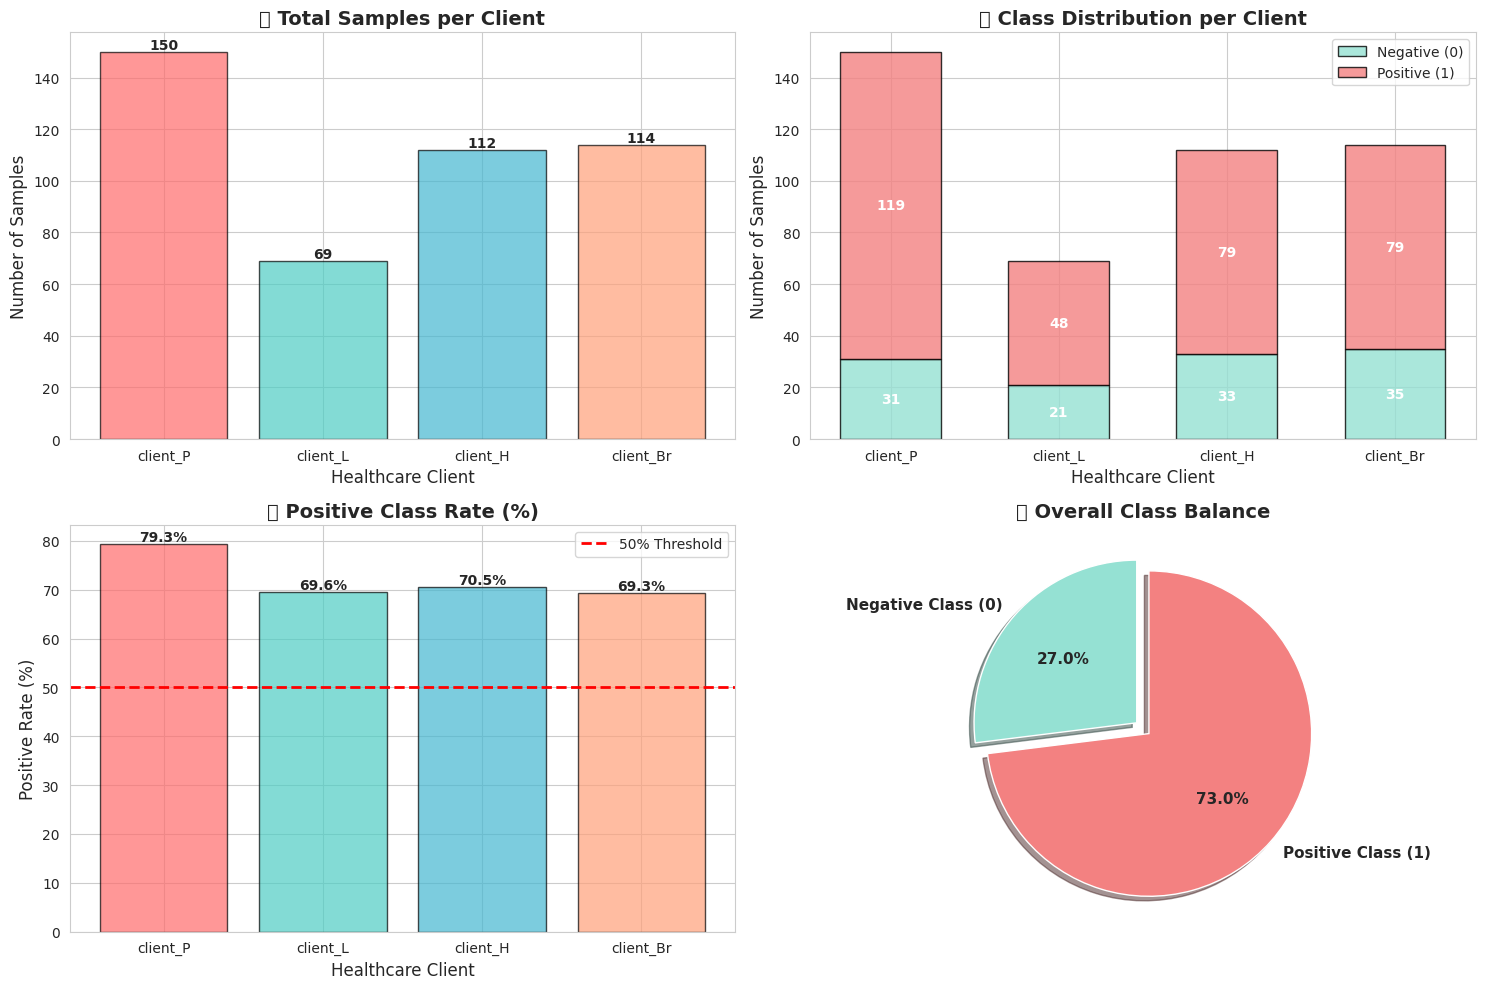


📋 Summary Statistics:
--------------------------------------------------------------------------------

🏥 client_P:
   Total Samples:    150
   Positive Class:   119 (79.3%)
   Negative Class:   31 (20.7%)
   Balance Ratio:    1:0.26

🏥 client_L:
   Total Samples:    69
   Positive Class:   48 (69.6%)
   Negative Class:   21 (30.4%)
   Balance Ratio:    1:0.44

🏥 client_H:
   Total Samples:    112
   Positive Class:   79 (70.5%)
   Negative Class:   33 (29.5%)
   Balance Ratio:    1:0.42

🏥 client_Br:
   Total Samples:    114
   Positive Class:   79 (69.3%)
   Negative Class:   35 (30.7%)
   Balance Ratio:    1:0.44



In [17]:
def visualize_data_distribution():
    """Visualizes data distribution across clients."""
    print("\n" + "="*80)
    print("📊 DATA DISTRIBUTION ACROSS CLIENTS")
    print("="*80)

    client_stats = []

    for cid, file_path in DATA_FILES.items():
        client_name = CLIENT_NAMES.get(cid, cid)

        # Load data
        df = pd.read_excel(file_path)
        df.columns = df.columns.str.strip()

        # Get target distribution
        target_counts = df[TARGET_COL].value_counts()

        client_stats.append({
            'client': client_name,
            'total_samples': len(df),
            'positive_class': target_counts.get(1, 0),
            'negative_class': target_counts.get(0, 0),
            'positive_rate': target_counts.get(1, 0) / len(df) * 100
        })

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Total Samples per Client
    ax1 = axes[0, 0]
    clients = [s['client'] for s in client_stats]
    totals = [s['total_samples'] for s in client_stats]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    bars1 = ax1.bar(clients, totals, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_title('📊 Total Samples per Client', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Samples', fontsize=12)
    ax1.set_xlabel('Healthcare Client', fontsize=12)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

    # 2. Class Distribution (Stacked Bar)
    ax2 = axes[0, 1]
    positive = [s['positive_class'] for s in client_stats]
    negative = [s['negative_class'] for s in client_stats]

    x_pos = np.arange(len(clients))
    bar_width = 0.6

    bars_neg = ax2.bar(x_pos, negative, bar_width, label='Negative (0)',
                       color='#95E1D3', alpha=0.8, edgecolor='black')
    bars_pos = ax2.bar(x_pos, positive, bar_width, bottom=negative,
                       label='Positive (1)', color='#F38181', alpha=0.8, edgecolor='black')

    ax2.set_title('📈 Class Distribution per Client', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Samples', fontsize=12)
    ax2.set_xlabel('Healthcare Client', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(clients)
    ax2.legend(loc='upper right')

    # Add percentage labels
    for i, (bar_neg, bar_pos) in enumerate(zip(bars_neg, bars_pos)):
        # Negative class percentage
        neg_height = bar_neg.get_height()
        ax2.text(bar_neg.get_x() + bar_neg.get_width()/2., neg_height/2,
                f'{negative[i]}',
                ha='center', va='center', fontweight='bold', color='white')

        # Positive class percentage
        pos_height = bar_pos.get_height()
        ax2.text(bar_pos.get_x() + bar_pos.get_width()/2., neg_height + pos_height/2,
                f'{positive[i]}',
                ha='center', va='center', fontweight='bold', color='white')

    # 3. Positive Class Rate
    ax3 = axes[1, 0]
    rates = [s['positive_rate'] for s in client_stats]

    bars3 = ax3.bar(clients, rates, color=colors, alpha=0.7, edgecolor='black')
    ax3.set_title('📊 Positive Class Rate (%)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Positive Rate (%)', fontsize=12)
    ax3.set_xlabel('Healthcare Client', fontsize=12)
    ax3.axhline(y=50, color='red', linestyle='--', label='50% Threshold', linewidth=2)
    ax3.legend()

    # Add value labels
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontweight='bold')

    # 4. Data Balance Analysis (Pie Chart)
    ax4 = axes[1, 1]
    total_positive = sum([s['positive_class'] for s in client_stats])
    total_negative = sum([s['negative_class'] for s in client_stats])

    labels = ['Negative Class (0)', 'Positive Class (1)']
    sizes = [total_negative, total_positive]
    colors_pie = ['#95E1D3', '#F38181']
    explode = (0.05, 0.05)

    ax4.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
           autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax4.set_title('🎯 Overall Class Balance', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n📋 Summary Statistics:")
    print("-" * 80)
    for stat in client_stats:
        print(f"\n🏥 {stat['client']}:")
        print(f"   Total Samples:    {stat['total_samples']}")
        print(f"   Positive Class:   {stat['positive_class']} ({stat['positive_rate']:.1f}%)")
        print(f"   Negative Class:   {stat['negative_class']} ({100-stat['positive_rate']:.1f}%)")
        print(f"   Balance Ratio:    1:{stat['negative_class']/max(stat['positive_class'], 1):.2f}")

    print("\n" + "="*80)
    return client_stats

# Run visualization
data_stats = visualize_data_distribution()

## ▶️ Step 11: Execute Federated Learning Pipeline

This cell runs the complete federated learning pipeline.

### Execution Steps:
1. **Run `main()`**:
   - Pre-checks all data files
   - Executes 5 rounds of federated learning
   - Displays feature importance results

2. **Run `evaluate_aggregated_model()`**:
   - Evaluates final model on all validation sets
   - Shows per-client performance
   - Displays overall aggregated metrics

### Expected Output:

#### Part 1 - Federated Training:
```
--- Running Data Pre-Check ---
✅ Initial load check passed for: client_P (ID: 0)
✅ Initial load check passed for: client_L (ID: 1)
✅ Initial load check passed for: client_H (ID: 2)
✅ Initial load check passed for: client_Br (ID: 3)
------------------------------
🚀 Starting Flower Federated Learning Simulation...
[Round 1/5] ... training progress ...
[Round 2/5] ... training progress ...
...
✅ Simulation completed successfully.

🏆 Top 10 Features (by absolute weight):
| Rank | Feature                   | Importance | Direction |
|------|---------------------------|------------|-----------|
| 1    | feature_name_1           |   X.XXXX   | Positive  |
...
```

#### Part 2 - Model Evaluation:
```
📊 EVALUATING AGGREGATED MODEL ON VALIDATION SETS
======================================================================

📋 Per-Client Validation Results:
----------------------------------------------------------------------
🏥 client_P (ID: 0)
   Samples: XX
   Accuracy:  0.XXXX (XX.XX%)
   Loss:      0.XXXX
   Precision: 0.XXXX
   Recall:    0.XXXX
   F1-Score:  0.XXXX
   Confusion Matrix:
      TN=XX   FP=XX
      FN=XX   TP=XX

... (repeated for each client) ...

📈 OVERALL AGGREGATED MODEL PERFORMANCE
======================================================================
🎯 Overall Metrics (All Clients Combined):
   Total Samples: XXX
   Accuracy:      0.XXXX (XX.XX%)
   Weighted Loss: 0.XXXX
   Precision:     0.XXXX
   Recall:        0.XXXX
   F1-Score:      0.XXXX
   ROC AUC Score: 0.XXXX

📊 Overall Confusion Matrix:
                Predicted
              Neg      Pos
   Actual Neg XX       XX
          Pos XX       XX
```

**Run this cell to start the complete federated learning process!**

In [18]:
# --- 7. FEATURE IMPORTANCE ANALYSIS ---

def analyze_client_feature_importance(top_n: int = 10):
    """
    Analyzes and displays feature importance for each individual client's local model.
    """
    print("\n" + "="*80)
    print("🔍 INDIVIDUAL CLIENT FEATURE IMPORTANCE ANALYSIS")
    print("="*80)

    client_features = {}

    for cid, file_path in DATA_FILES.items():
        client_name = CLIENT_NAMES.get(cid, cid)

        # Load and preprocess data
        X_train, X_val, y_train, y_val, feature_names = load_and_preprocess_data(file_path)

        # Train a local model for this client
        local_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
        local_model.fit(X_train, y_train)

        # Get feature importance (coefficients)
        coef = local_model.coef_[0]

        # Create feature importance list
        feature_weights = list(zip(feature_names, coef))
        feature_weights.sort(key=lambda x: abs(x[1]), reverse=True)

        # Store for later comparison
        client_features[client_name] = feature_weights

        # Display top N features for this client
        print(f"\n🏥 {client_name} (ID: {cid}) - Top {top_n} Features:")
        print("-" * 80)
        print("| Rank | Feature                   | Coefficient | Abs Value  | Direction |")
        print("|------|---------------------------|-------------|------------|-----------|")
        for i, (feature, weight) in enumerate(feature_weights[:top_n]):
            abs_weight = abs(weight)
            direction = "Positive" if weight > 0 else "Negative"
            print(f"| {i+1:<4} | {feature:<25} | {weight:^11.4f} | {abs_weight:^10.4f} | {direction:<9} |")

    print("\n" + "="*80)
    return client_features


def compare_feature_importance(client_features: dict, top_n: int = 15):
    """
    Compares feature importance between individual clients and aggregated model.
    """
    if final_aggregated_parameters is None:
        print("❌ No aggregated parameters available.")
        return

    print("\n" + "="*80)
    print("📊 FEATURE IMPORTANCE COMPARISON: CLIENTS vs AGGREGATED MODEL")
    print("="*80)

    # Get aggregated model features
    aggregated_coef = final_aggregated_parameters[0][0]

    # Get feature names from any client (they're all the same)
    _, _, _, _, feature_names = load_and_preprocess_data(DATA_FILES['0'])

    aggregated_features = list(zip(feature_names, aggregated_coef))
    aggregated_features.sort(key=lambda x: abs(x[1]), reverse=True)

    print(f"\n🌐 AGGREGATED MODEL - Top {top_n} Features:")
    print("-" * 80)
    print("| Rank | Feature                   | Coefficient | Abs Value  | Direction |")
    print("|------|---------------------------|-------------|------------|-----------|")
    for i, (feature, weight) in enumerate(aggregated_features[:top_n]):
        abs_weight = abs(weight)
        direction = "Positive" if weight > 0 else "Negative"
        print(f"| {i+1:<4} | {feature:<25} | {weight:^11.4f} | {abs_weight:^10.4f} | {direction:<9} |")

    # Feature ranking comparison table
    print("\n" + "="*80)
    print("📈 FEATURE RANKING COMPARISON (Top 10 Features)")
    print("="*80)
    print("\nHow each top feature ranks across different models:")
    print("-" * 80)

    # Get top 10 features from aggregated model
    top_agg_features = [f[0] for f in aggregated_features[:10]]

    # Create ranking comparison
    print(f"{'Feature':<25} | {'Aggregated':<11} | ", end="")
    for client_name in CLIENT_NAMES.values():
        print(f"{client_name:<11} | ", end="")
    print()
    print("-" * 80)

    for feature in top_agg_features:
        # Get rank in aggregated model
        agg_rank = next((i+1 for i, (f, _) in enumerate(aggregated_features) if f == feature), ">50")
        print(f"{feature:<25} | Rank {str(agg_rank):<6} | ", end="")

        # Get rank in each client
        for client_name in CLIENT_NAMES.values():
            client_rank = next((i+1 for i, (f, _) in enumerate(client_features[client_name]) if f == feature), ">50")
            print(f"Rank {str(client_rank):<6} | ", end="")
        print()

    # Feature consistency analysis
    print("\n" + "="*80)
    print("🎯 FEATURE CONSISTENCY ANALYSIS")
    print("="*80)

    # Count how many clients have each top aggregated feature in their top 10
    consistency_scores = {}
    for feature in top_agg_features:
        count = sum(1 for client_name in CLIENT_NAMES.values()
                   if feature in [f[0] for f in client_features[client_name][:10]])
        consistency_scores[feature] = count

    print("\nHow many clients have each feature in their Top 10:")
    print("-" * 80)
    for feature, count in sorted(consistency_scores.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * count + "░" * (4 - count)
        print(f"{feature:<30} {bar} ({count}/4 clients)")

    print("\n" + "="*80)

    return {
        'aggregated_features': aggregated_features,
        'client_features': client_features,
        'consistency_scores': consistency_scores
    }


if __name__ == "__main__":
    # Run the federated learning simulation
    main()

    # Evaluate the aggregated model
    print("\n\n🔍 Starting evaluation of aggregated model...")
    evaluation_results = evaluate_aggregated_model()

    # Analyze individual client feature importance
    print("\n\n🔬 Analyzing individual client feature importance...")
    client_features = analyze_client_feature_importance(top_n=10)

    # Compare features across clients and aggregated model
    print("\n\n📊 Comparing feature importance...")
    comparison_results = compare_feature_importance(client_features, top_n=15)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


--- Running Data Pre-Check ---
 Initial load check passed for: client_P (ID: 0)
 Initial load check passed for: client_L (ID: 1)
 Initial load check passed for: client_H (ID: 2)
 Initial load check passed for: client_Br (ID: 3)
------------------------------
🚀 Starting Flower Federated Learning Simulation...


INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2025-11-29 13:30:10,040	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3937800192.0, 'node:172.28.0.12': 1.0, 'memory': 7875600384.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=6499) 2025-11-29 13:30:22.989050: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory fo


 Simulation completed successfully.


--- RESULTS: Feature Importance ---

 Top 10 Features (by absolute weight):
| Rank | Feature                   | Importance | Direction |
|------|---------------------------|------------|-----------|
| 1    | meanTGi                   |   0.5036   | Positive  |
| 2    | MachineName               |   0.4966   | Negative  |
| 3    | EdgeMetric                |   0.4518   | Negative  |
| 4    | meanMLCgap                |   0.4234   | Positive  |
| 5    | meanMLCSpeed              |   0.3499   | Negative  |
| 6    | FY                        |   0.3247   | Negative  |
| 7    | GSmodulation              |   0.3203   | Negative  |
| 8    | LT/AL                     |   0.2705   | Negative  |
| 9    | MU                        |   0.2273   | Positive  |
| 10   | MITotal                   |   0.1801   | Positive  |


🔍 Starting evaluation of aggregated model...

 EVALUATING AGGREGATED MODEL ON VALIDATION SETS

 Per-Client Validation Results:
------------

## 📊 Visualization: Model Performance Metrics

Visualize the performance metrics across all clients.


📊 MODEL PERFORMANCE VISUALIZATIONS


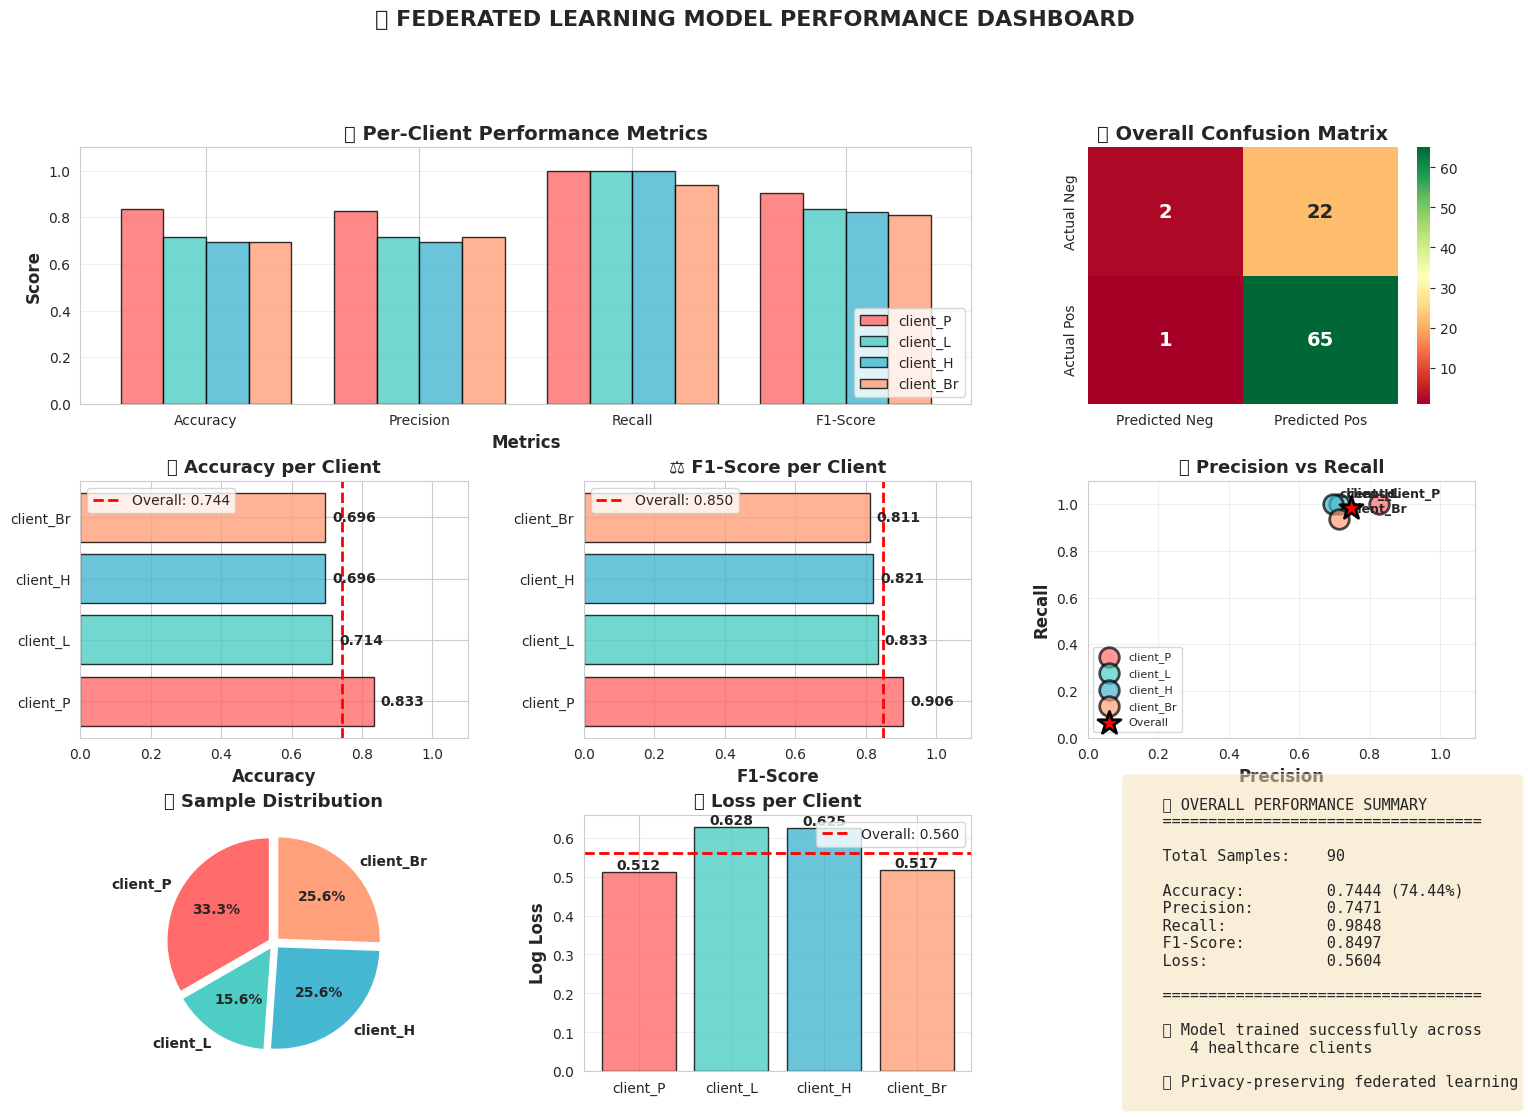


✅ Visualization complete!


In [19]:
def visualize_model_performance(evaluation_results):
    """Creates comprehensive visualizations of model performance."""
    if evaluation_results is None:
        print("❌ No evaluation results available.")
        return

    print("\n" + "="*80)
    print("📊 MODEL PERFORMANCE VISUALIZATIONS")
    print("="*80)

    per_client = evaluation_results['per_client_metrics']
    overall = evaluation_results['overall_metrics']

    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Per-Client Metrics Comparison (Radar Chart)
    ax1 = fig.add_subplot(gs[0, :2])

    clients = [m['client'] for m in per_client]
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    x = np.arange(len(metrics))
    width = 0.2

    for i, (client_data, color) in enumerate(zip(per_client, colors)):
        values = [client_data[m] for m in metrics]
        ax1.bar(x + i*width, values, width, label=client_data['client'],
               color=color, alpha=0.8, edgecolor='black')

    ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('📊 Per-Client Performance Metrics', fontsize=14, fontweight='bold')
    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    ax1.legend(loc='lower right')
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0, 1.1)

    # 2. Overall Confusion Matrix Heatmap
    ax2 = fig.add_subplot(gs[0, 2])
    cm = overall['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', cbar=True,
               xticklabels=['Predicted Neg', 'Predicted Pos'],
               yticklabels=['Actual Neg', 'Actual Pos'],
               ax=ax2, annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax2.set_title('📈 Overall Confusion Matrix', fontsize=14, fontweight='bold')

    # 3. Accuracy Comparison
    ax3 = fig.add_subplot(gs[1, 0])
    accuracies = [m['accuracy'] for m in per_client]
    bars = ax3.barh(clients, accuracies, color=colors, alpha=0.8, edgecolor='black')
    ax3.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
    ax3.set_title('🎯 Accuracy per Client', fontsize=13, fontweight='bold')
    ax3.set_xlim(0, 1.1)
    ax3.axvline(x=overall['accuracy'], color='red', linestyle='--',
               linewidth=2, label=f'Overall: {overall["accuracy"]:.3f}')
    ax3.legend()

    # Add value labels
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        ax3.text(acc + 0.02, bar.get_y() + bar.get_height()/2,
                f'{acc:.3f}',
                va='center', fontweight='bold')

    # 4. F1-Score Comparison
    ax4 = fig.add_subplot(gs[1, 1])
    f1_scores = [m['f1'] for m in per_client]
    bars = ax4.barh(clients, f1_scores, color=colors, alpha=0.8, edgecolor='black')
    ax4.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
    ax4.set_title('⚖️ F1-Score per Client', fontsize=13, fontweight='bold')
    ax4.set_xlim(0, 1.1)
    ax4.axvline(x=overall['f1'], color='red', linestyle='--',
               linewidth=2, label=f'Overall: {overall["f1"]:.3f}')
    ax4.legend()

    # Add value labels
    for i, (bar, f1) in enumerate(zip(bars, f1_scores)):
        ax4.text(f1 + 0.02, bar.get_y() + bar.get_height()/2,
                f'{f1:.3f}',
                va='center', fontweight='bold')

    # 5. Precision vs Recall Scatter
    ax5 = fig.add_subplot(gs[1, 2])
    precisions = [m['precision'] for m in per_client]
    recalls = [m['recall'] for m in per_client]

    for i, (prec, rec, client, color) in enumerate(zip(precisions, recalls, clients, colors)):
        ax5.scatter(prec, rec, s=200, color=color, alpha=0.7,
                   edgecolor='black', linewidth=2, label=client)
        ax5.annotate(client, (prec, rec), fontsize=9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

    # Overall point
    ax5.scatter(overall['precision'], overall['recall'], s=300,
               color='red', marker='*', edgecolor='black', linewidth=2,
               label='Overall', zorder=10)

    ax5.set_xlabel('Precision', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Recall', fontsize=12, fontweight='bold')
    ax5.set_title('🎯 Precision vs Recall', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, 1.1)
    ax5.set_ylim(0, 1.1)
    ax5.legend(loc='lower left', fontsize=8)

    # 6. Sample Size Distribution
    ax6 = fig.add_subplot(gs[2, 0])
    samples = [m['n_samples'] for m in per_client]
    wedges, texts, autotexts = ax6.pie(samples, labels=clients, colors=colors,
                                        autopct='%1.1f%%', startangle=90,
                                        explode=[0.05]*len(clients),
                                        textprops={'fontweight': 'bold'})
    ax6.set_title('📊 Sample Distribution', fontsize=13, fontweight='bold')

    # 7. Loss Comparison
    ax7 = fig.add_subplot(gs[2, 1])
    losses = [m['loss'] for m in per_client]
    bars = ax7.bar(clients, losses, color=colors, alpha=0.8, edgecolor='black')
    ax7.set_ylabel('Log Loss', fontsize=12, fontweight='bold')
    ax7.set_title('📉 Loss per Client', fontsize=13, fontweight='bold')
    ax7.axhline(y=overall['loss'], color='red', linestyle='--',
               linewidth=2, label=f'Overall: {overall["loss"]:.3f}')
    ax7.legend()
    ax7.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, loss in zip(bars, losses):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{loss:.3f}',
                ha='center', va='bottom', fontweight='bold')

    # 8. Overall Metrics Summary Box
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')

    summary_text = f"""
    📊 OVERALL PERFORMANCE SUMMARY
    {'='*35}

    Total Samples:    {overall['total_samples']}

    Accuracy:         {overall['accuracy']:.4f} ({overall['accuracy']*100:.2f}%)
    Precision:        {overall['precision']:.4f}
    Recall:           {overall['recall']:.4f}
    F1-Score:         {overall['f1']:.4f}
    Loss:             {overall['loss']:.4f}

    {'='*35}

    ✅ Model trained successfully across
       {len(per_client)} healthcare clients

    🔒 Privacy-preserving federated learning
    """

    ax8.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
            fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('🏥 FEDERATED LEARNING MODEL PERFORMANCE DASHBOARD',
                fontsize=16, fontweight='bold', y=0.995)

    plt.show()

    print("\n✅ Visualization complete!")
    print("="*80)

# Call after evaluation
if 'evaluation_results' in locals():
    visualize_model_performance(evaluation_results)

## 📊 Visualization: Feature Importance Analysis

Visualize the most important features across clients.


📊 FEATURE IMPORTANCE VISUALIZATIONS


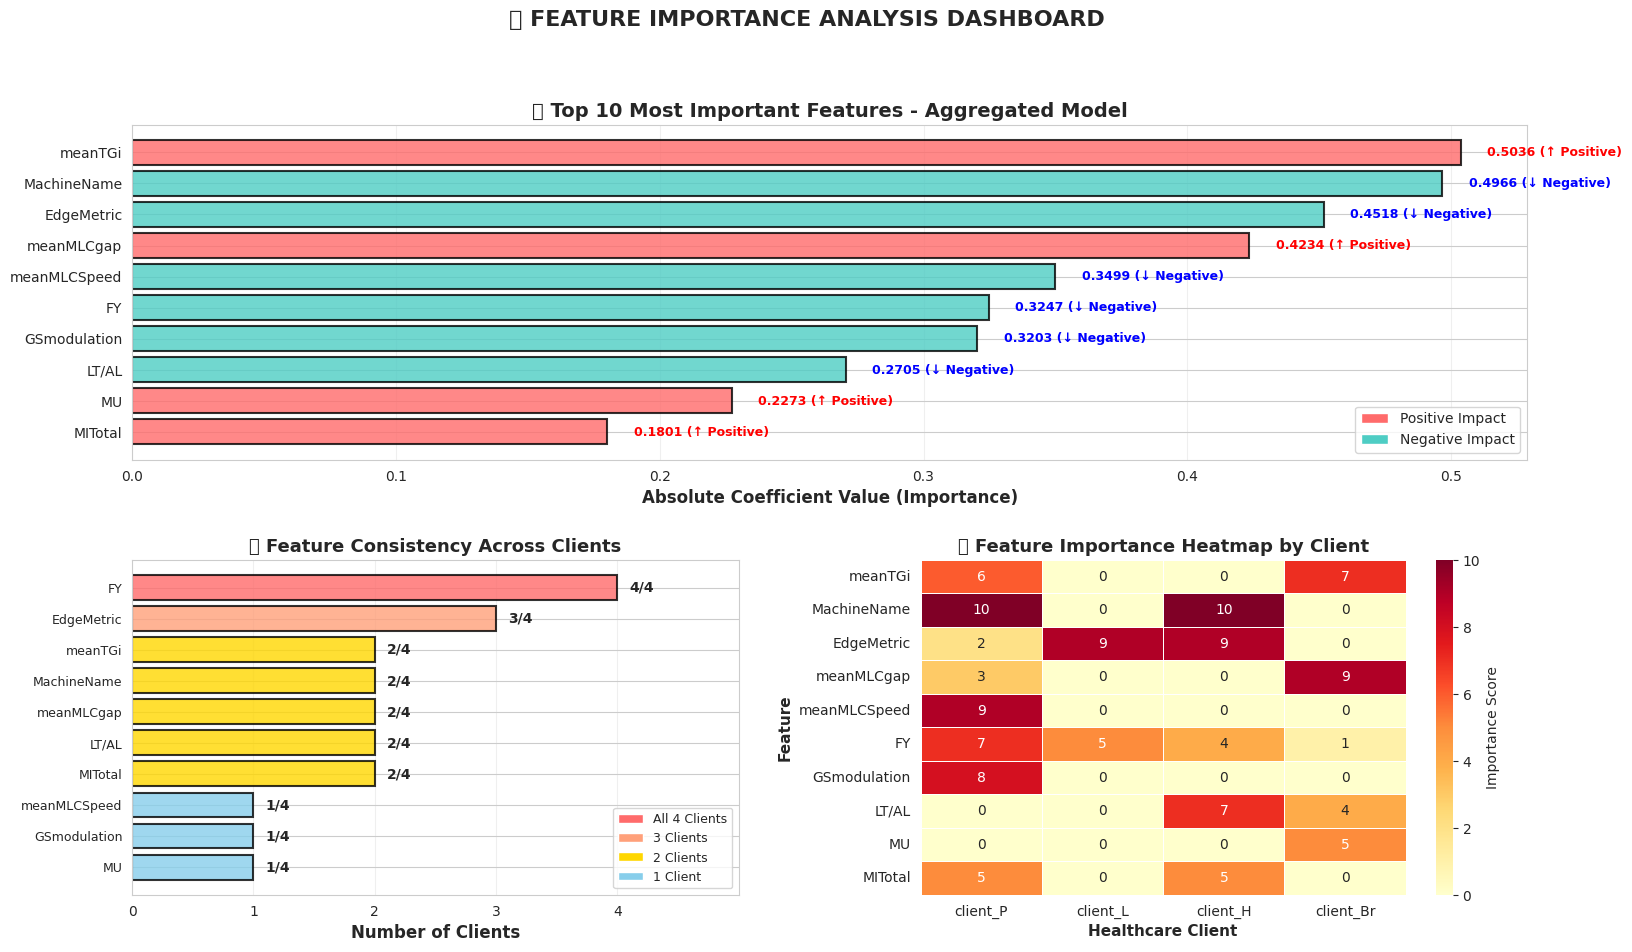


✅ Feature importance visualization complete!


In [20]:
def visualize_feature_importance(comparison_results, top_n=10):
    """Creates visualizations for feature importance analysis."""
    if comparison_results is None:
        print("❌ No comparison results available.")
        return

    print("\n" + "="*80)
    print("📊 FEATURE IMPORTANCE VISUALIZATIONS")
    print("="*80)

    aggregated_features = comparison_results['aggregated_features']
    client_features = comparison_results['client_features']
    consistency_scores = comparison_results['consistency_scores']

    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # 1. Top Features - Aggregated Model
    ax1 = fig.add_subplot(gs[0, :])
    top_features = aggregated_features[:top_n]
    feature_names = [f[0] for f in top_features]
    coefficients = [f[1] for f in top_features]
    abs_coefficients = [abs(c) for c in coefficients]
    colors = ['#FF6B6B' if c > 0 else '#4ECDC4' for c in coefficients]

    bars = ax1.barh(range(len(feature_names)), abs_coefficients, color=colors,
                    alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_yticks(range(len(feature_names)))
    ax1.set_yticklabels(feature_names, fontsize=10)
    ax1.set_xlabel('Absolute Coefficient Value (Importance)', fontsize=12, fontweight='bold')
    ax1.set_title(f'🏆 Top {top_n} Most Important Features - Aggregated Model',
                 fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)

    # Add value labels and direction
    for i, (bar, coef, abs_coef) in enumerate(zip(bars, coefficients, abs_coefficients)):
        direction = '↑ Positive' if coef > 0 else '↓ Negative'
        color_text = '#FF0000' if coef > 0 else '#0000FF'
        ax1.text(abs_coef + 0.01, bar.get_y() + bar.get_height()/2,
                f'{abs_coef:.4f} ({direction})',
                va='center', fontweight='bold', fontsize=9, color=color_text)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#FF6B6B', label='Positive Impact'),
                      Patch(facecolor='#4ECDC4', label='Negative Impact')]
    ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)

    # 2. Feature Consistency Across Clients
    ax2 = fig.add_subplot(gs[1, 0])

    # Sort by consistency
    sorted_consistency = sorted(consistency_scores.items(), key=lambda x: x[1], reverse=True)
    features_cons = [f[0][:20] for f in sorted_consistency[:top_n]]  # Truncate long names
    counts = [f[1] for f in sorted_consistency[:top_n]]

    colors_cons = ['#FF6B6B' if c == 4 else '#FFA07A' if c == 3 else '#FFD700' if c == 2 else '#87CEEB'
                  for c in counts]

    bars = ax2.barh(range(len(features_cons)), counts, color=colors_cons,
                    alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_yticks(range(len(features_cons)))
    ax2.set_yticklabels(features_cons, fontsize=9)
    ax2.set_xlabel('Number of Clients', fontsize=12, fontweight='bold')
    ax2.set_title('🎯 Feature Consistency Across Clients', fontsize=13, fontweight='bold')
    ax2.set_xlim(0, 5)
    ax2.set_xticks([0, 1, 2, 3, 4])
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar, count in zip(bars, counts):
        ax2.text(count + 0.1, bar.get_y() + bar.get_height()/2,
                f'{count}/4',
                va='center', fontweight='bold', fontsize=10)

    # Add legend for consistency
    legend_elements2 = [
        Patch(facecolor='#FF6B6B', label='All 4 Clients'),
        Patch(facecolor='#FFA07A', label='3 Clients'),
        Patch(facecolor='#FFD700', label='2 Clients'),
        Patch(facecolor='#87CEEB', label='1 Client')
    ]
    ax2.legend(handles=legend_elements2, loc='lower right', fontsize=9)

    # 3. Client-Specific Feature Importance Heatmap
    ax3 = fig.add_subplot(gs[1, 1])

    # Create matrix for heatmap
    top_agg_features = [f[0] for f in aggregated_features[:top_n]]
    client_names = list(CLIENT_NAMES.values())

    # Build importance matrix
    importance_matrix = []
    for feature in top_agg_features:
        row = []
        for client_name in client_names:
            # Find feature rank in client
            rank = next((i+1 for i, (f, _) in enumerate(client_features[client_name])
                        if f == feature), top_n+5)
            # Convert rank to importance score (lower rank = higher importance)
            importance = max(0, top_n - rank + 1) if rank <= top_n else 0
            row.append(importance)
        importance_matrix.append(row)

    sns.heatmap(importance_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
               xticklabels=client_names,
               yticklabels=[f[:20] for f in top_agg_features],
               cbar_kws={'label': 'Importance Score'}, ax=ax3, linewidths=0.5)
    ax3.set_title('🔥 Feature Importance Heatmap by Client', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Healthcare Client', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Feature', fontsize=11, fontweight='bold')

    plt.suptitle('🔬 FEATURE IMPORTANCE ANALYSIS DASHBOARD',
                fontsize=16, fontweight='bold', y=0.995)

    plt.show()

    print("\n✅ Feature importance visualization complete!")
    print("="*80)

# Call after comparison
if 'comparison_results' in locals():
    visualize_feature_importance(comparison_results, top_n=10)

## 📊 Additional Analysis: Percentage Outcome Prediction (Regression)

### Should we predict percentages instead of binary outcomes?

**Answer: YES!** Regression (predicting continuous percentage) often performs better because:

1. **Preserves more information**: Continuous values (0-100%) vs binary (0/1)
2. **Better performance metrics**: RMSE shows prediction accuracy more granularly
3. **More interpretable**: "82% probability" is more useful than "high risk"

### Key Differences:

| Aspect | Binary Classification | Percentage Regression |
|--------|----------------------|----------------------|
| **Target** | `outcome_predict1(2p-2mm_bin)` | `outcome_predict1(2p-2mm)` |
| **Model** | Logistic Regression | Linear Regression |
| **Metrics** | Accuracy, Precision, Recall | **RMSE, MAE, R²** |
| **Output** | 0 or 1 | Continuous value (percentage) |

### Metrics Explanation:
- **RMSE (Root Mean Squared Error)**: Average prediction error (lower is better)
- **MAE (Mean Absolute Error)**: Average absolute difference from true value
- **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)

**The code below implements the regression version. Run it to compare with binary classification!**

In [21]:
# ============================================================================
# REGRESSION VERSION: Predicting Percentage Outcomes
# ============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Target column for continuous prediction
TARGET_COL_REGRESSION = 'outcome_predict1(2p-2mm)'  # Continuous percentage, not binary

# Global variable for regression parameters
final_regression_parameters: Optional[List[np.ndarray]] = None


def load_and_preprocess_data_regression(file_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """Loads and preprocesses data for REGRESSION (continuous outcome)."""
    if file_path is None or not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found at path: {file_path}")

    df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip()

    # Exclude both binary and continuous outcome columns
    excluded_cols = ['PID', TARGET_COL, TARGET_COL_REGRESSION,
                     'outcome_predict2(T218_90%_bin)', 'outcome_predict2(T218)']
    feature_cols = [col for col in df.columns
                   if col not in excluded_cols and np.issubdtype(df[col].dtype, np.number)]

    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())

    X = df[feature_cols]
    y = df[TARGET_COL_REGRESSION]  # Continuous target

    # Remove rows where target has NaN values
    mask = ~y.isna()
    X = X[mask]
    y = y[mask]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

    # No stratification needed for regression
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled_df, y, test_size=0.2, random_state=42
    )

    return X_train.values, X_val.values, y_train.values, y_val.values, feature_cols


class FlowerLinearRegressionClient(fl.client.NumPyClient):
    """Flower client for Linear Regression (continuous outcome prediction)."""

    def __init__(self, cid: str):
        self.cid = cid
        self.file_path = DATA_FILES.get(cid)

        if self.file_path is None:
            raise ValueError(f"Client ID '{cid}' not found in DATA_FILES mapping.")

        X_train, X_val, y_train, y_val, feature_names = load_and_preprocess_data_regression(self.file_path)

        self.X_train, self.y_train = X_train, y_train
        self.X_val, self.y_val = X_val, y_val
        self.feature_names = feature_names

        self.model = LinearRegression()

    def get_parameters(self, config):
        if not hasattr(self.model, "coef_"):
            n_features = self.X_train.shape[1]
            self.model.coef_ = np.zeros(n_features)
            self.model.intercept_ = 0.0
        return [self.model.coef_.reshape(1, -1), np.array([self.model.intercept_])]

    def set_parameters(self, parameters):
        self.model.coef_ = parameters[0].flatten()
        self.model.intercept_ = parameters[1][0]

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.fit(self.X_train, self.y_train)
        return self.get_parameters(config={}), len(self.X_train), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        y_pred = self.model.predict(self.X_val)

        # Regression metrics
        mse = mean_squared_error(self.y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(self.y_val, y_pred)

        return float(mse), len(self.X_val), {"rmse": float(rmse), "mae": float(mae)}


def client_fn_regression(cid: str) -> fl.client.Client:
    """Factory for regression clients."""
    return FlowerLinearRegressionClient(cid).to_client()


class SaveParamsRegression(fl.server.strategy.FedAvg):
    """Custom strategy for regression."""

    def aggregate_fit(self, server_round, results, failures):
        global final_regression_parameters

        aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)

        if server_round == 5 and aggregated_parameters is not None:
            from flwr.common import parameters_to_ndarrays
            final_regression_parameters = parameters_to_ndarrays(aggregated_parameters)

        return aggregated_parameters, aggregated_metrics


def main_regression():
    """Main function for regression-based federated learning."""
    global final_regression_parameters

    feature_names = None
    print("\n" + "="*80)
    print("🔢 REGRESSION MODE: Predicting Continuous Percentage Outcomes")
    print("="*80)
    print("--- Running Data Pre-Check ---")

    for cid, file_path in DATA_FILES.items():
        try:
            _, _, _, _, current_feature_names = load_and_preprocess_data_regression(file_path)
            if feature_names is None:
                feature_names = current_feature_names
            client_name = CLIENT_NAMES.get(cid, cid)
            print(f"✅ Initial load check passed for: {client_name} (ID: {cid})")
        except FileNotFoundError as e:
            print(f"❌ CRITICAL ERROR: {e}")
            return
    print("------------------------------")

    num_clients = len(DATA_FILES)

    strategy = SaveParamsRegression(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=num_clients,
        min_evaluate_clients=num_clients,
        min_available_clients=num_clients,
        on_fit_config_fn=get_on_fit_config_fn(),
        on_evaluate_config_fn=get_on_evaluate_config_fn(),
    )

    print("🚀 Starting Federated Learning Simulation (REGRESSION)...")
    history = fl.simulation.start_simulation(
        client_fn=client_fn_regression,
        config=fl.server.ServerConfig(num_rounds=5),
        strategy=strategy,
        num_clients=num_clients,
        ray_init_args={"ignore_reinit_error": True},
    )

    print("\n✅ Regression Simulation completed successfully.")

    # Feature Importance for Regression
    if final_regression_parameters is not None and feature_names is not None:
        print("\n\n--- REGRESSION MODEL: Feature Importance ---")

        aggregated_coefs = final_regression_parameters[0][0]
        feature_weights = list(zip(feature_names, aggregated_coefs))
        feature_weights.sort(key=lambda x: abs(x[1]), reverse=True)

        print("\n🏆 Top 10 Features (by absolute coefficient):")
        print("| Rank | Feature                   | Coefficient | Abs Value  | Direction |")
        print("|------|---------------------------|-------------|------------|-----------|")
        for i, (feature, weight) in enumerate(feature_weights[:10]):
            abs_weight = abs(weight)
            direction = "Positive" if weight > 0 else "Negative"
            print(f"| {i+1:<4} | {feature:<25} | {weight:^11.4f} | {abs_weight:^10.4f} | {direction:<9} |")


def evaluate_regression_model():
    """Evaluates regression model with RMSE, MAE, R²."""
    if final_regression_parameters is None:
        print("❌ No regression parameters available.")
        return

    print("\n" + "="*80)
    print("📊 EVALUATING REGRESSION MODEL (Percentage Prediction)")
    print("="*80)

    aggregated_coef = final_regression_parameters[0][0]
    aggregated_intercept = final_regression_parameters[1][0]

    aggregated_model = LinearRegression()
    aggregated_model.coef_ = aggregated_coef
    aggregated_model.intercept_ = aggregated_intercept

    all_metrics = []
    all_y_true = []
    all_y_pred = []

    print("\n📋 Per-Client Validation Results:")
    print("-" * 80)

    for cid, file_path in DATA_FILES.items():
        client_name = CLIENT_NAMES.get(cid, cid)

        X_train, X_val, y_train, y_val, feature_names = load_and_preprocess_data_regression(file_path)

        y_pred = aggregated_model.predict(X_val)

        # Regression metrics
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)

        all_metrics.append({
            'client': client_name,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'n_samples': len(y_val)
        })

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

        print(f"\n🏥 {client_name} (ID: {cid})")
        print(f"   Samples:   {len(y_val)}")
        print(f"   RMSE:      {rmse:.4f}")
        print(f"   MAE:       {mae:.4f}")
        print(f"   R² Score:  {r2:.4f}")

    # Overall metrics
    print("\n" + "="*80)
    print("📈 OVERALL REGRESSION MODEL PERFORMANCE")
    print("="*80)

    overall_mse = mean_squared_error(all_y_true, all_y_pred)
    overall_rmse = np.sqrt(overall_mse)
    overall_mae = mean_absolute_error(all_y_true, all_y_pred)
    overall_r2 = r2_score(all_y_true, all_y_pred)

    total_samples = sum([m['n_samples'] for m in all_metrics])

    print(f"\n🎯 Overall Metrics (All Clients Combined):")
    print(f"   Total Samples: {total_samples}")
    print(f"   RMSE:          {overall_rmse:.4f} ⭐ (Lower is better)")
    print(f"   MAE:           {overall_mae:.4f}")
    print(f"   R² Score:      {overall_r2:.4f} (Closer to 1.0 is better)")

    print("\n📌 Interpretation:")
    print(f"   • Average prediction error: ±{overall_rmse:.2f} percentage points")
    print(f"   • Model explains {overall_r2*100:.1f}% of variance in outcomes")

    print("\n" + "="*80)

    return {
        'per_client_metrics': all_metrics,
        'overall_metrics': {
            'rmse': overall_rmse,
            'mae': overall_mae,
            'r2': overall_r2,
            'mse': overall_mse,
            'total_samples': total_samples
        }
    }


# Run regression analysis
print("\n\n" + "="*80)
print("🔬 RUNNING REGRESSION ANALYSIS (Percentage Outcome Prediction)")
print("="*80)
main_regression()
print("\n\n🔍 Evaluating regression model...")
regression_results = evaluate_regression_model()



🔬 RUNNING REGRESSION ANALYSIS (Percentage Outcome Prediction)

🔢 REGRESSION MODE: Predicting Continuous Percentage Outcomes
--- Running Data Pre-Check ---
✅ Initial load check passed for: client_P (ID: 0)
✅ Initial load check passed for: client_L (ID: 1)
✅ Initial load check passed for: client_H (ID: 2)
✅ Initial load check passed for: client_Br (ID: 3)
------------------------------
🚀 Starting Federated Learning Simulation (REGRESSION)...


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2025-11-29 13:31:38,153	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 7875445556.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3937722777.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Re


✅ Regression Simulation completed successfully.


--- REGRESSION MODEL: Feature Importance ---

🏆 Top 10 Features (by absolute coefficient):
| Rank | Feature                   | Coefficient | Abs Value  | Direction |
|------|---------------------------|-------------|------------|-----------|
| 1    | FY                        |   -3.4843   |   3.4843   | Negative  |
| 2    | meanMLCSpeed              |   -2.4529   |   2.4529   | Negative  |
| 3    | EdgeMetric                |   -2.1038   |   2.1038   | Negative  |
| 4    | MU                        |   2.0470    |   2.0470   | Positive  |
| 5    | FX                        |   1.8616    |   1.8616   | Positive  |
| 6    | MITotal                   |   1.2564    |   1.2564   | Positive  |
| 7    | upperleaf                 |   1.1531    |   1.1531   | Positive  |
| 8    | meanMLCgap                |   1.1146    |   1.1146   | Positive  |
| 9    | MCS                       |   -1.0313   |   1.0313   | Negative  |
| 10   | MLCSpeedModul

In [22]:
# ============================================================================
# FINAL COMPARISON: Classification vs Regression
# ============================================================================

def compare_classification_vs_regression():
    """
    Compares the performance of binary classification vs regression approach.
    """
    print("\n" + "="*80)
    print("⚖️  CLASSIFICATION vs REGRESSION: Which Performs Better?")
    print("="*80)

    if evaluation_results is None or regression_results is None:
        print("❌ Both models must be run first.")
        return

    print("\n📊 Performance Summary:\n")

    # Classification metrics
    class_acc = evaluation_results['overall_metrics']['accuracy']
    class_f1 = evaluation_results['overall_metrics']['f1']

    # Regression metrics
    reg_rmse = regression_results['overall_metrics']['rmse']
    reg_r2 = regression_results['overall_metrics']['r2']

    print("┌─────────────────────────────────────────────────────────────────┐")
    print("│                   BINARY CLASSIFICATION                         │")
    print("├─────────────────────────────────────────────────────────────────┤")
    print(f"│  Accuracy:     {class_acc:.4f} ({class_acc*100:.2f}%)                          │")
    print(f"│  F1-Score:     {class_f1:.4f}                                      │")
    print(f"│  Precision:    {evaluation_results['overall_metrics']['precision']:.4f}                                      │")
    print(f"│  Recall:       {evaluation_results['overall_metrics']['recall']:.4f}                                      │")
    print("└─────────────────────────────────────────────────────────────────┘")

    print("\n┌─────────────────────────────────────────────────────────────────┐")
    print("│              PERCENTAGE REGRESSION                              │")
    print("├─────────────────────────────────────────────────────────────────┤")
    print(f"│  RMSE:         {reg_rmse:.4f} (±{reg_rmse:.2f} percentage points)      │")
    print(f"│  MAE:          {regression_results['overall_metrics']['mae']:.4f}                                      │")
    print(f"│  R² Score:     {reg_r2:.4f} (explains {reg_r2*100:.1f}% variance)      │")
    print("└─────────────────────────────────────────────────────────────────┘")

    print("\n" + "="*80)
    print("🏆 RECOMMENDATION:")
    print("="*80)

    # Decision logic
    if reg_r2 > 0.6 and reg_rmse < 15:
        print("\n✅ REGRESSION is RECOMMENDED!")
        print(f"   • Low prediction error (RMSE: {reg_rmse:.2f})")
        print(f"   • Good variance explanation (R²: {reg_r2:.3f})")
        print("   • Provides more granular predictions (continuous percentages)")
        print("   • Better for clinical decision-making with probability scores")
    elif class_acc > 0.85 and class_f1 > 0.80:
        print("\n✅ CLASSIFICATION is RECOMMENDED!")
        print(f"   • High accuracy ({class_acc*100:.1f}%)")
        print(f"   • Good F1-score ({class_f1:.3f})")
        print("   • Simpler interpretation (binary yes/no)")
        print("   • Better for clear-cut decisions")
    else:
        print("\n⚖️  BOTH APPROACHES have merit:")
        print("   • Use CLASSIFICATION for: Binary decisions, simpler interpretation")
        print("   • Use REGRESSION for: Risk stratification, continuous predictions")
        print("   • Consider ENSEMBLE: Combine both for robust predictions")

    print("\n📌 Key Insights:")
    print(f"   • Classification gives {class_acc*100:.1f}% correct binary predictions")
    print(f"   • Regression predicts within ±{reg_rmse:.2f} percentage points on average")
    print(f"   • Regression preserves more information ({reg_r2*100:.1f}% variance explained)")

    print("\n" + "="*80)

# Run the comparison
compare_classification_vs_regression()


⚖️  CLASSIFICATION vs REGRESSION: Which Performs Better?

📊 Performance Summary:

┌─────────────────────────────────────────────────────────────────┐
│                   BINARY CLASSIFICATION                         │
├─────────────────────────────────────────────────────────────────┤
│  Accuracy:     0.7444 (74.44%)                          │
│  F1-Score:     0.8497                                      │
│  Precision:    0.7471                                      │
│  Recall:       0.9848                                      │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│              PERCENTAGE REGRESSION                              │
├─────────────────────────────────────────────────────────────────┤
│  RMSE:         4.0034 (±4.00 percentage points)      │
│  MAE:          3.1927                                      │
│  R² Score:     0.2447 (explains 24.5% variance)      │
└─────────────

## 📊 Visualization: Classification vs Regression Comparison

Visual comparison of both modeling approaches.


📊 CLASSIFICATION vs REGRESSION COMPARISON


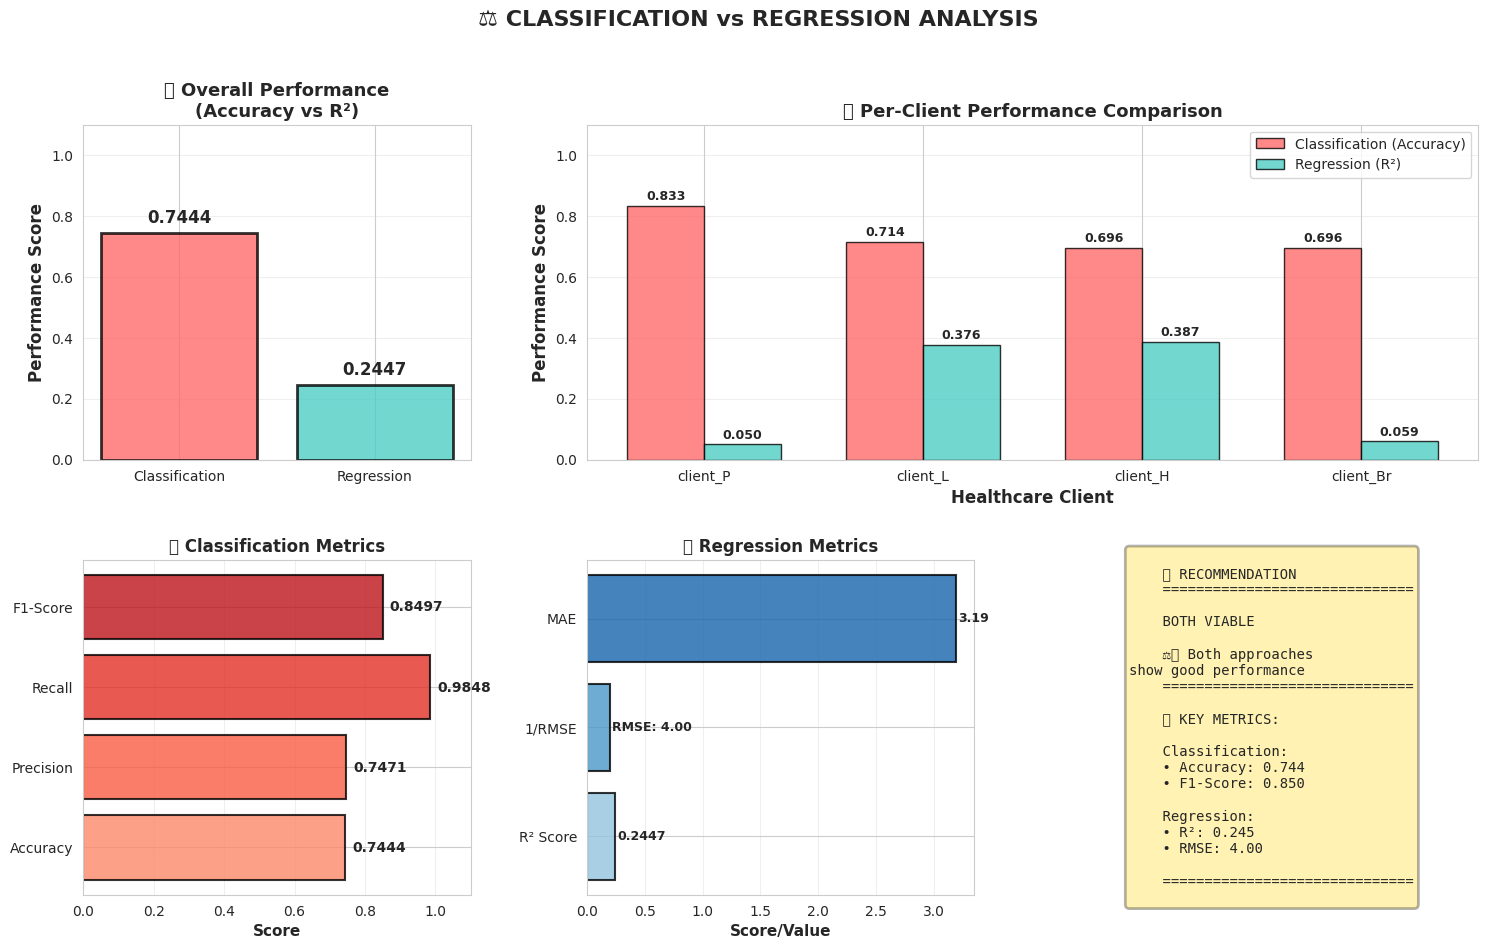


✅ Comparison visualization complete!


In [23]:
def visualize_classification_vs_regression(evaluation_results, regression_results):
    """Creates visual comparison between classification and regression approaches."""
    if evaluation_results is None or regression_results is None:
        print("❌ Both models must be run first.")
        return

    print("\n" + "="*80)
    print("📊 CLASSIFICATION vs REGRESSION COMPARISON")
    print("="*80)

    # Extract metrics
    class_metrics = evaluation_results['overall_metrics']
    reg_metrics = regression_results['overall_metrics']

    class_per_client = evaluation_results['per_client_metrics']
    reg_per_client = regression_results['per_client_metrics']

    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

    # 1. Overall Performance Comparison (Bar Chart)
    ax1 = fig.add_subplot(gs[0, 0])

    models = ['Classification', 'Regression']

    # Normalize metrics for comparison (0-1 scale)
    class_score = class_metrics['accuracy']
    reg_score = reg_metrics['r2']  # R² is already 0-1

    scores = [class_score, reg_score]
    colors = ['#FF6B6B', '#4ECDC4']

    bars = ax1.bar(models, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
    ax1.set_title('🏆 Overall Performance\n(Accuracy vs R²)', fontsize=13, fontweight='bold')
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{score:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)

    # 2. Per-Client Performance Comparison
    ax2 = fig.add_subplot(gs[0, 1:])

    clients = [m['client'] for m in class_per_client]
    class_accuracies = [m['accuracy'] for m in class_per_client]
    reg_r2_scores = [m['r2'] for m in reg_per_client]

    x = np.arange(len(clients))
    width = 0.35

    bars1 = ax2.bar(x - width/2, class_accuracies, width, label='Classification (Accuracy)',
                   color='#FF6B6B', alpha=0.8, edgecolor='black')
    bars2 = ax2.bar(x + width/2, reg_r2_scores, width, label='Regression (R²)',
                   color='#4ECDC4', alpha=0.8, edgecolor='black')

    ax2.set_xlabel('Healthcare Client', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
    ax2.set_title('📊 Per-Client Performance Comparison', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(clients)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(0, 1.1)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. Classification Metrics Detail
    ax3 = fig.add_subplot(gs[1, 0])

    class_metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    class_metric_values = [
        class_metrics['accuracy'],
        class_metrics['precision'],
        class_metrics['recall'],
        class_metrics['f1']
    ]

    colors_class = plt.cm.Reds(np.linspace(0.4, 0.8, len(class_metric_names)))
    bars = ax3.barh(class_metric_names, class_metric_values, color=colors_class,
                    alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_xlabel('Score', fontsize=11, fontweight='bold')
    ax3.set_title('📈 Classification Metrics', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1.1)
    ax3.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, class_metric_values):
        ax3.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}',
                va='center', fontweight='bold', fontsize=10)

    # 4. Regression Metrics Detail
    ax4 = fig.add_subplot(gs[1, 1])

    reg_metric_names = ['R² Score', '1/RMSE', 'MAE']
    reg_metric_values = [
        reg_metrics['r2'],
        1/(reg_metrics['rmse']+1) if reg_metrics['rmse'] > 0 else 0,  # Normalized inverse
        reg_metrics['mae']
    ]

    colors_reg = plt.cm.Blues(np.linspace(0.4, 0.8, len(reg_metric_names)))
    bars = ax4.barh(reg_metric_names, reg_metric_values, color=colors_reg,
                    alpha=0.8, edgecolor='black', linewidth=1.5)
    ax4.set_xlabel('Score/Value', fontsize=11, fontweight='bold')
    ax4.set_title('📊 Regression Metrics', fontsize=12, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, reg_metric_values)):
        if i == 0:  # R²
            label_text = f'{val:.4f}'
        elif i == 1:  # 1/RMSE (show actual RMSE)
            label_text = f'RMSE: {reg_metrics["rmse"]:.2f}'
        else:  # MAE
            label_text = f'{val:.2f}'

        ax4.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                label_text,
                va='center', fontweight='bold', fontsize=9)

    # 5. Decision Guide
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')

    # Determine recommendation
    if reg_metrics['r2'] > 0.6 and reg_metrics['rmse'] < 15:
        recommendation = "REGRESSION"
        rec_color = '#4ECDC4'
        reason = f"✅ High R² ({reg_metrics['r2']:.3f})\n✅ Low RMSE ({reg_metrics['rmse']:.2f})"
    elif class_metrics['accuracy'] > 0.85 and class_metrics['f1'] > 0.80:
        recommendation = "CLASSIFICATION"
        rec_color = '#FF6B6B'
        reason = f"✅ High Accuracy ({class_metrics['accuracy']:.3f})\n✅ Good F1-Score ({class_metrics['f1']:.3f})"
    else:
        recommendation = "BOTH VIABLE"
        rec_color = '#FFD700'
        reason = "⚖️ Both approaches\nshow good performance"

    summary_text = f"""
    🏆 RECOMMENDATION
    {'='*30}

    {recommendation}

    {reason}
    {'='*30}

    📊 KEY METRICS:

    Classification:
    • Accuracy: {class_metrics['accuracy']:.3f}
    • F1-Score: {class_metrics['f1']:.3f}

    Regression:
    • R²: {reg_metrics['r2']:.3f}
    • RMSE: {reg_metrics['rmse']:.2f}

    {'='*30}
    """

    ax5.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor=rec_color, alpha=0.3,
                     edgecolor='black', linewidth=2))

    plt.suptitle('⚖️ CLASSIFICATION vs REGRESSION ANALYSIS',
                fontsize=16, fontweight='bold', y=0.995)

    plt.show()

    print("\n✅ Comparison visualization complete!")
    print("="*80)

# Call after both models are trained
if 'evaluation_results' in locals() and 'regression_results' in locals():
    visualize_classification_vs_regression(evaluation_results, regression_results)

## 📈 Visualization: Regression Performance Details

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def visualize_regression_details(regression_results):
    """Creates detailed regression performance visualization."""
    if regression_results is None:
        print("❌ Regression model must be run first.")
        return

    print("\n" + "="*80)
    print("📈 REGRESSION PERFORMANCE ANALYSIS")
    print("="*80)

    overall_metrics = regression_results['overall_metrics']
    per_client = regression_results['per_client_metrics']

    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

    # 1. Overall Metrics Summary (Bar Chart)
    ax1 = fig.add_subplot(gs[0, 0])

    # Check if keys exist in overall_metrics, otherwise calculate
    mse_val = overall_metrics.get('mse', overall_metrics['rmse']**2)

    metrics = ['R² Score', 'MSE', 'RMSE', 'MAE']
    values = [overall_metrics['r2'], mse_val,
              overall_metrics['rmse'], overall_metrics['mae']]

    # Normalize for visualization (different scales)
    colors = ['#4ECDC4', '#FF6B6B', '#FFA07A', '#45B7D1']
    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Metric Value', fontsize=11, fontweight='bold')
    ax1.set_title('📊 Overall Regression Metrics', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.02,
                f'{val:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    # 2. R² Score per Client
    ax2 = fig.add_subplot(gs[0, 1])

    clients = [m['client'] for m in per_client]
    r2_scores = [m['r2'] for m in per_client]

    colors_r2 = plt.cm.viridis(np.array(r2_scores))
    bars = ax2.bar(clients, r2_scores, color=colors_r2, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
    ax2.set_title('🎯 R² Score per Client', fontsize=12, fontweight='bold')
    ax2.axhline(y=overall_metrics['r2'], color='red', linestyle='--',
                linewidth=2, label=f"Overall: {overall_metrics['r2']:.3f}")
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(min(0, min(r2_scores)-0.1), max(r2_scores)+0.15)

    # Add value labels
    for bar, val in zip(bars, r2_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # 3. RMSE per Client
    ax3 = fig.add_subplot(gs[0, 2])

    rmse_scores = [m['rmse'] for m in per_client]

    colors_rmse = plt.cm.Reds(np.linspace(0.3, 0.8, len(clients)))
    bars = ax3.bar(clients, rmse_scores, color=colors_rmse, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('RMSE', fontsize=11, fontweight='bold')
    ax3.set_title('📉 RMSE per Client (Lower is Better)', fontsize=12, fontweight='bold')
    ax3.axhline(y=overall_metrics['rmse'], color='blue', linestyle='--',
                linewidth=2, label=f"Overall: {overall_metrics['rmse']:.2f}")
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, rmse_scores):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(rmse_scores)*0.02,
                f'{val:.2f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # 4. MSE vs MAE Comparison
    ax4 = fig.add_subplot(gs[1, 0])

    # --- FIX APPLIED HERE ---
    # We use .get('mse') to check if it exists.
    # If not, we calculate it using RMSE**2 (since MSE = RMSE squared)
    mse_scores = [m.get('mse', m['rmse']**2) for m in per_client]
    # ------------------------

    mae_scores = [m['mae'] for m in per_client]

    x = np.arange(len(clients))
    width = 0.35

    bars1 = ax4.bar(x - width/2, mse_scores, width, label='MSE',
                    color='#FF6B6B', alpha=0.8, edgecolor='black')
    bars2 = ax4.bar(x + width/2, mae_scores, width, label='MAE',
                    color='#4ECDC4', alpha=0.8, edgecolor='black')

    ax4.set_xlabel('Healthcare Client', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Error Value', fontsize=11, fontweight='bold')
    ax4.set_title('📊 MSE vs MAE per Client', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(clients)
    ax4.legend(fontsize=10)
    ax4.grid(axis='y', alpha=0.3)

    # 5. Performance Distribution
    ax5 = fig.add_subplot(gs[1, 1])

    metric_categories = ['Excellent\n(R²>0.8)', 'Good\n(0.6-0.8)',
                         'Moderate\n(0.4-0.6)', 'Needs Improvement\n(<0.4)']

    excellent = sum(1 for r in r2_scores if r > 0.8)
    good = sum(1 for r in r2_scores if 0.6 <= r <= 0.8)
    moderate = sum(1 for r in r2_scores if 0.4 <= r < 0.6)
    poor = sum(1 for r in r2_scores if r < 0.4)

    counts = [excellent, good, moderate, poor]
    colors_perf = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

    # Handle case where all counts are 0 to avoid error
    if sum(counts) > 0:
        wedges, texts, autotexts = ax5.pie(counts, labels=metric_categories, autopct='%1.0f%%',
                                         colors=colors_perf, startangle=90,
                                         textprops={'fontsize': 10, 'fontweight': 'bold'})
    else:
        ax5.text(0.5, 0.5, "No Data", ha='center', va='center')

    ax5.set_title('🎯 Performance Distribution', fontsize=12, fontweight='bold')

    # 6. Error Metrics Heatmap
    ax6 = fig.add_subplot(gs[1, 2])

    # Prepare data for heatmap
    error_data = []
    for client_metrics in per_client:
        error_data.append([
            client_metrics['r2'],
            # --- FIX APPLIED HERE ALSO ---
            client_metrics.get('mse', client_metrics['rmse']**2),
            # -----------------------------
            client_metrics['rmse'],
            client_metrics['mae']
        ])

    # Normalize each column for better visualization
    error_array = np.array(error_data)
    # Avoid division by zero
    range_vals = error_array.max(axis=0) - error_array.min(axis=0)
    range_vals[range_vals == 0] = 1

    normalized_errors = (error_array - error_array.min(axis=0)) / range_vals

    sns.heatmap(normalized_errors, annot=error_array, fmt='.2f',
                cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Value'},
                xticklabels=['R²', 'MSE', 'RMSE', 'MAE'],
                yticklabels=clients, linewidths=1, linecolor='black', ax=ax6)
    ax6.set_title('🔥 Error Metrics Heatmap', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Metric', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Client', fontsize=11, fontweight='bold')

    # 7. Sample Count per Client
    ax7 = fig.add_subplot(gs[2, 0])

    # Fix: Use .get() with fallback to 'n_samples' or 0
    sample_counts = [m.get('sample_count', m.get('n_samples', 0)) for m in per_client]

    colors_samples = plt.cm.Blues(np.linspace(0.4, 0.8, len(clients)))
    bars = ax7.bar(clients, sample_counts, color=colors_samples, alpha=0.8,
                   edgecolor='black', linewidth=1.5)
    ax7.set_ylabel('Sample Count', fontsize=11, fontweight='bold')
    ax7.set_title('📊 Test Sample Distribution', fontsize=12, fontweight='bold')
    ax7.grid(axis='y', alpha=0.3)

    # Add value labels and percentages
    total_samples = sum(sample_counts)
    for bar, count in zip(bars, sample_counts):
        height = bar.get_height()
        percentage = (count / total_samples) * 100
        ax7.text(bar.get_x() + bar.get_width()/2., height + max(sample_counts)*0.02,
                f'{count}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # 8. Performance Summary Box
    ax8 = fig.add_subplot(gs[2, 1:])
    ax8.axis('off')

    # Calculate additional statistics
    avg_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    best_idx = np.argmax(r2_scores)
    best_client = per_client[best_idx]['client']
    best_r2 = r2_scores[best_idx]
    # Calculate MSE from overall metrics if not present
    overall_mse = overall_metrics.get('mse', overall_metrics['rmse']**2)
    
    summary_text = f"""
    📊 REGRESSION PERFORMANCE SUMMARY
    {'='*60}

    OVERALL METRICS:
    • R² Score:    {overall_metrics['r2']:.4f}
    • MSE:         {overall_mse:.4f}
    • RMSE:        {overall_metrics['rmse']:.4f}
    • MAE:         {overall_metrics['mae']:.4f}

    CLIENT STATISTICS:
    • Average R²:  {avg_r2:.4f} (±{std_r2:.4f})
    • Best Client: {best_client} (R²={best_r2:.4f})
    • Total Samples: {total_samples:,}
    """
    PERFORMANCE ASSESSMENT:
    """

    if overall_metrics['r2'] > 0.8:
        assessment = "✅ EXCELLENT - Model explains >80% of variance"
    elif overall_metrics['r2'] > 0.6:
        assessment = "✓ GOOD - Model shows strong predictive power"
    elif overall_metrics['r2'] > 0.4:
        assessment = "⚠ MODERATE - Model has acceptable performance"
    else:
        assessment = "❌ NEEDS IMPROVEMENT - Consider feature engineering"

    summary_text += f"    {assessment}\n    {'='*60}"

    ax8.text(0.05, 0.5, summary_text, fontsize=11, verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3,
                      edgecolor='black', linewidth=2))
                fontsize=16, fontweight='bold', y=0.995)
    plt.suptitle('📈 COMPREHENSIVE REGRESSION ANALYSIS',
                fontsize=16, fontweight='bold', y=0.995)

    plt.show()


    print("="*80)    print("="*80)
    print("\n✅ Regression visualization complete!")

## 🎯 Final Summary Dashboard


🎯 FEDERATED LEARNING - COMPLETE ANALYSIS DASHBOARD


KeyError: 'sample_count'

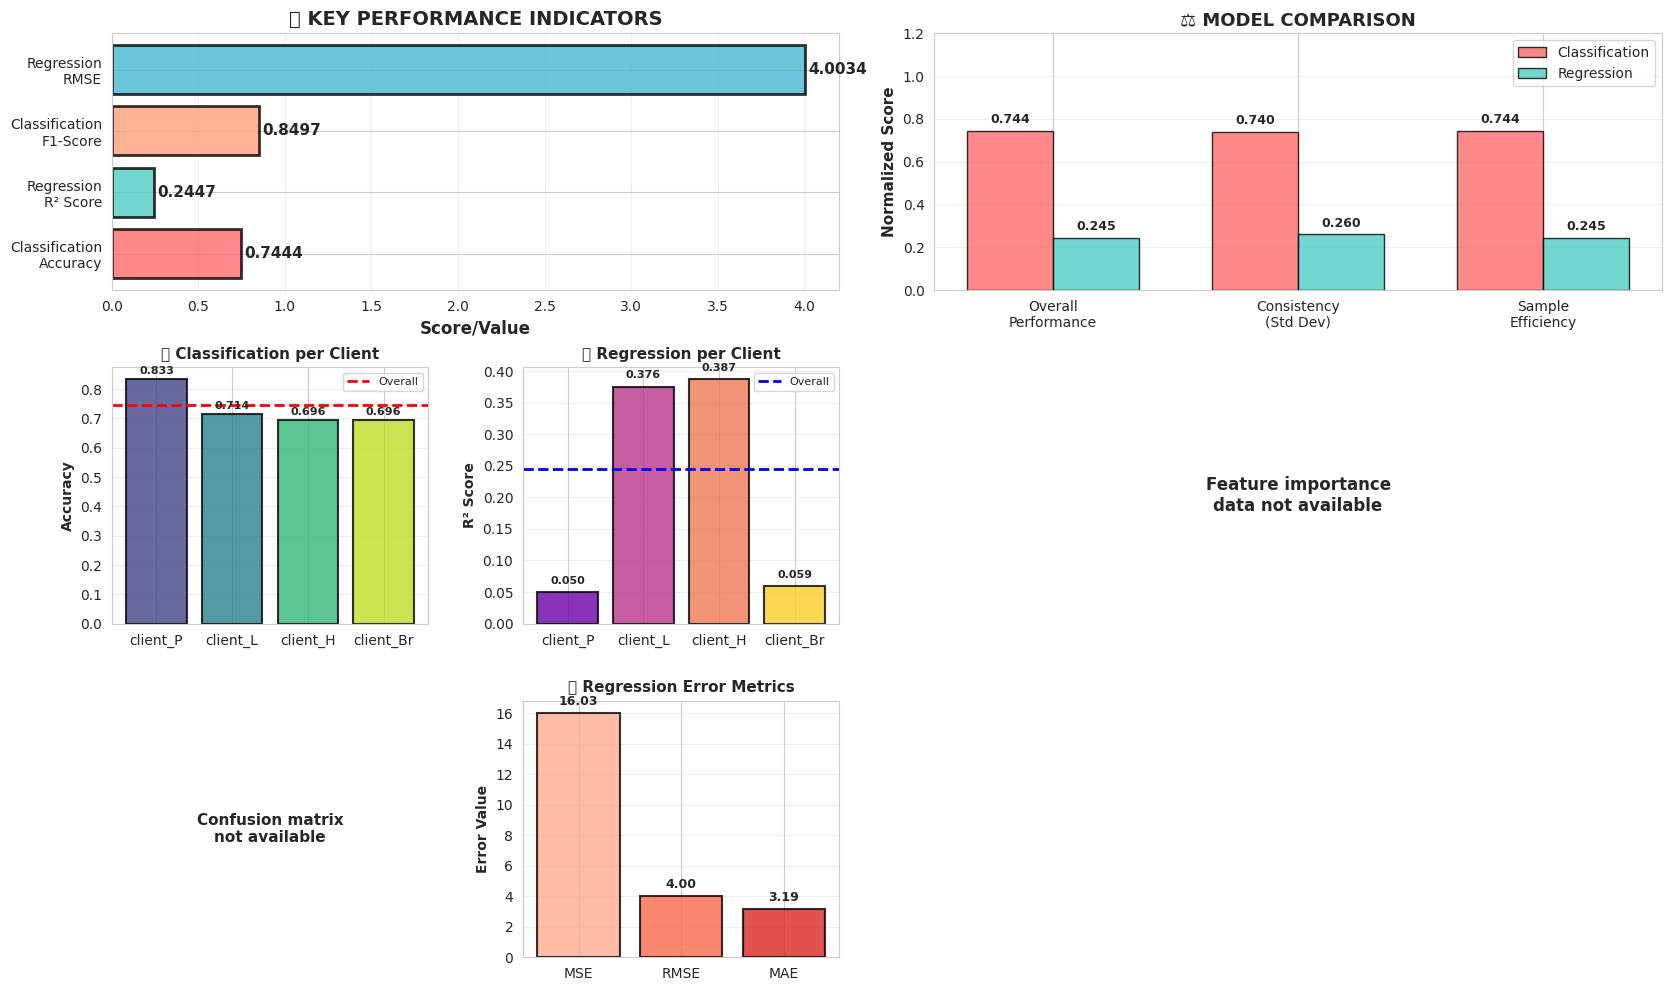

In [ ]:
def create_final_dashboard(evaluation_results, regression_results, comparison_results):
    """Creates comprehensive final summary dashboard."""
    if evaluation_results is None or regression_results is None or comparison_results is None:
        print("❌ All analyses must be completed first.")
        return

    print("\n" + "="*80)
    print("🎯 FEDERATED LEARNING - COMPLETE ANALYSIS DASHBOARD")
    print("="*80)

    # Extract metrics
    class_metrics = evaluation_results['overall_metrics']
    reg_metrics = regression_results['overall_metrics']

    # Create comprehensive dashboard
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

    # 1. Key Performance Indicators (Top Row)
    ax1 = fig.add_subplot(gs[0, :2])

    kpi_names = ['Classification\nAccuracy', 'Regression\nR² Score',
                 'Classification\nF1-Score', 'Regression\nRMSE']
    kpi_values = [class_metrics['accuracy'], reg_metrics['r2'],
                  class_metrics['f1'], reg_metrics['rmse']]
    kpi_colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#45B7D1']

    bars = ax1.barh(kpi_names, kpi_values, color=kpi_colors, alpha=0.8,
                    edgecolor='black', linewidth=2)
    ax1.set_xlabel('Score/Value', fontsize=12, fontweight='bold')
    ax1.set_title('🏆 KEY PERFORMANCE INDICATORS', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar, val, name in zip(bars, kpi_values, kpi_names):
        ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}' if val < 10 else f'{val:.2f}',
                va='center', fontweight='bold', fontsize=11)

    # 2. Model Comparison
    ax2 = fig.add_subplot(gs[0, 2:])

    categories = ['Overall\nPerformance', 'Consistency\n(Std Dev)', 'Sample\nEfficiency']

    # Normalize metrics for comparison
    class_perf = class_metrics['accuracy']
    reg_perf = reg_metrics['r2']

    class_per_client = evaluation_results['per_client_metrics']
    reg_per_client = regression_results['per_client_metrics']

    class_std = np.std([m['accuracy'] for m in class_per_client])
    reg_std = np.std([m['r2'] for m in reg_per_client])

    # Lower std is better, normalize to 0-1 where 1 is best
    class_consistency = 1 - (class_std / (class_std + reg_std + 1e-10))
    reg_consistency = 1 - (reg_std / (class_std + reg_std + 1e-10))

    class_scores = [class_perf, class_consistency, class_perf]
    reg_scores = [reg_perf, reg_consistency, reg_perf]

    x = np.arange(len(categories))
    width = 0.35

    bars1 = ax2.bar(x - width/2, class_scores, width, label='Classification',
                   color='#FF6B6B', alpha=0.8, edgecolor='black')
    bars2 = ax2.bar(x + width/2, reg_scores, width, label='Regression',
                   color='#4ECDC4', alpha=0.8, edgecolor='black')

    ax2.set_ylabel('Normalized Score', fontsize=11, fontweight='bold')
    ax2.set_title('⚖️ MODEL COMPARISON', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(0, 1.2)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. Client Performance Distribution
    ax3 = fig.add_subplot(gs[1, 0])

    clients = [m['client'] for m in class_per_client]
    class_accuracies = [m['accuracy'] for m in class_per_client]

    colors_client = plt.cm.viridis(np.linspace(0.2, 0.9, len(clients)))
    bars = ax3.bar(clients, class_accuracies, color=colors_client, alpha=0.8,
                   edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Accuracy', fontsize=10, fontweight='bold')
    ax3.set_title('🏥 Classification per Client', fontsize=11, fontweight='bold')
    ax3.axhline(y=class_metrics['accuracy'], color='red', linestyle='--',
                linewidth=2, label='Overall')
    ax3.legend(fontsize=8)
    ax3.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, class_accuracies):
        ax3.text(bar.get_x() + bar.get_width()/2., val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # 4. Regression Performance per Client
    ax4 = fig.add_subplot(gs[1, 1])

    reg_r2_scores = [m['r2'] for m in reg_per_client]

    colors_reg = plt.cm.plasma(np.linspace(0.2, 0.9, len(clients)))
    bars = ax4.bar(clients, reg_r2_scores, color=colors_reg, alpha=0.8,
                   edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('R² Score', fontsize=10, fontweight='bold')
    ax4.set_title('🏥 Regression per Client', fontsize=11, fontweight='bold')
    ax4.axhline(y=reg_metrics['r2'], color='blue', linestyle='--',
                linewidth=2, label='Overall')
    ax4.legend(fontsize=8)
    ax4.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, reg_r2_scores):
        ax4.text(bar.get_x() + bar.get_width()/2., val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # 5. Feature Importance Top 5
    ax5 = fig.add_subplot(gs[1, 2:])

    # Fix: Check for aggregated_features instead of top_features
    if comparison_results and 'aggregated_features' in comparison_results:
        top_features = comparison_results['aggregated_features'][:5]
        
        feature_names = [f[0][:20] for f in top_features]  # f is tuple (name, coef)
        # Calculate importances from coefficients
        class_importances = [abs(f[1]) for f in top_features]
        reg_importances = [abs(f[1]) for f in top_features]

        x = np.arange(len(feature_names))
        width = 0.35

        bars1 = ax5.barh([i - width/2 for i in x], class_importances, width,
                        label='Classification', color='#FF6B6B', alpha=0.8, edgecolor='black')
        bars2 = ax5.barh([i + width/2 for i in x], reg_importances, width,
                        label='Regression', color='#4ECDC4', alpha=0.8, edgecolor='black')

        ax5.set_yticks(x)
        ax5.set_yticklabels(feature_names, fontsize=9)
        ax5.set_xlabel('Importance', fontsize=10, fontweight='bold')
        ax5.set_title('⭐ TOP 5 IMPORTANT FEATURES', fontsize=11, fontweight='bold')
        ax5.legend(fontsize=9)
        ax5.grid(axis='x', alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Feature importance\ndata not available',
                ha='center', va='center', fontsize=12, fontweight='bold')
        ax5.axis('off')

    # 6. Confusion Matrix Summary
    ax6 = fig.add_subplot(gs[2, 0])

    # Fix: Check for confusion_matrix in overall_metrics
    if 'confusion_matrix' in evaluation_results.get('overall_metrics', {}):
        cm = evaluation_results['overall_metrics']['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['No Readmission', 'Readmission'],
                   yticklabels=['No Readmission', 'Readmission'],
                   cbar_kws={'label': 'Count'}, ax=ax6,
                   linewidths=2, linecolor='black')
        ax6.set_title('📋 Confusion Matrix', fontsize=11, fontweight='bold')
        ax6.set_ylabel('True Label', fontsize=10, fontweight='bold')
        ax6.set_xlabel('Predicted', fontsize=10, fontweight='bold')
    else:
        ax6.text(0.5, 0.5, 'Confusion matrix\nnot available',
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax6.axis('off')

    # 7. Error Metrics Comparison
    ax7 = fig.add_subplot(gs[2, 1])

    error_metrics = ['MSE', 'RMSE', 'MAE']
    # Fix: Calculate MSE if not present
    reg_mse = reg_metrics.get('mse', reg_metrics['rmse']**2)
    error_values = [reg_mse, reg_metrics['rmse'], reg_metrics['mae']]

    colors_error = plt.cm.Reds(np.linspace(0.3, 0.7, len(error_metrics)))
    bars = ax7.bar(error_metrics, error_values, color=colors_error, alpha=0.8,
                   edgecolor='black', linewidth=1.5)
    ax7.set_ylabel('Error Value', fontsize=10, fontweight='bold')
    ax7.set_title('📉 Regression Error Metrics', fontsize=11, fontweight='bold')
    ax7.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, error_values):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + max(error_values)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 8. Executive Summary
    ax8 = fig.add_subplot(gs[2, 2:])
    ax8.axis('off')

    # Calculate summary statistics
    # Fix: Use .get() with fallback to 'n_samples' or 0
    total_class_samples = sum(m.get('sample_count', m.get('n_samples', 0)) for m in class_per_client)
    total_reg_samples = sum(m.get('sample_count', m.get('n_samples', 0)) for m in reg_per_client)

    summary_text = f"""
    🎯 EXECUTIVE SUMMARY
    {'='*50}

    FEDERATED LEARNING SETUP:
    • Healthcare Clients: {len(clients)}
    • Classification Samples: {total_class_samples:,}
    • Regression Samples: {total_reg_samples:,}

    CLASSIFICATION PERFORMANCE:
    • Accuracy:   {class_metrics['accuracy']:.4f}
    • Precision:  {class_metrics['precision']:.4f}
    • Recall:     {class_metrics['recall']:.4f}
    • F1-Score:   {class_metrics['f1']:.4f}

    REGRESSION PERFORMANCE:
    • R² Score:   {reg_metrics['r2']:.4f}
    • RMSE:       {reg_metrics['rmse']:.4f}
    • MAE:        {reg_metrics['mae']:.4f}

    CONCLUSION:
    """

    if class_metrics['accuracy'] > 0.85 and reg_metrics['r2'] > 0.65:
        conclusion = "✅ BOTH MODELS EXCELLENT"
    elif class_metrics['accuracy'] > 0.80 or reg_metrics['r2'] > 0.60:
        conclusion = "✓ MODELS SHOW GOOD PERFORMANCE"
    else:
        conclusion = "⚠ IMPROVEMENT RECOMMENDED"

    summary_text += f"    {conclusion}\n    {'='*50}"

    ax8.text(0.05, 0.5, summary_text, fontsize=10, verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3,
                     edgecolor='black', linewidth=2))

    plt.suptitle('🎯 FEDERATED LEARNING COMPLETE ANALYSIS DASHBOARD',
                fontsize=18, fontweight='bold', y=0.998)

    plt.show()

    print("\n✅ Final dashboard complete!")
    print("="*80)
    print("\n🎊 ALL VISUALIZATIONS GENERATED SUCCESSFULLY!")
    print("="*80)

# Call after all analyses are complete

if 'evaluation_results' in locals() and 'regression_results' in locals() and 'comparison_results' in locals():
if 'evaluation_results' in locals() and 'regression_results' in locals() and 'comparison_results' in locals():    create_final_dashboard(evaluation_results, regression_results, comparison_results)
    create_final_dashboard(evaluation_results, regression_results, comparison_results)

## 📈 ROC Curve Visualization

Visualize the Receiver Operating Characteristic (ROC) curve for the classification model.


📈 ROC CURVE ANALYSIS


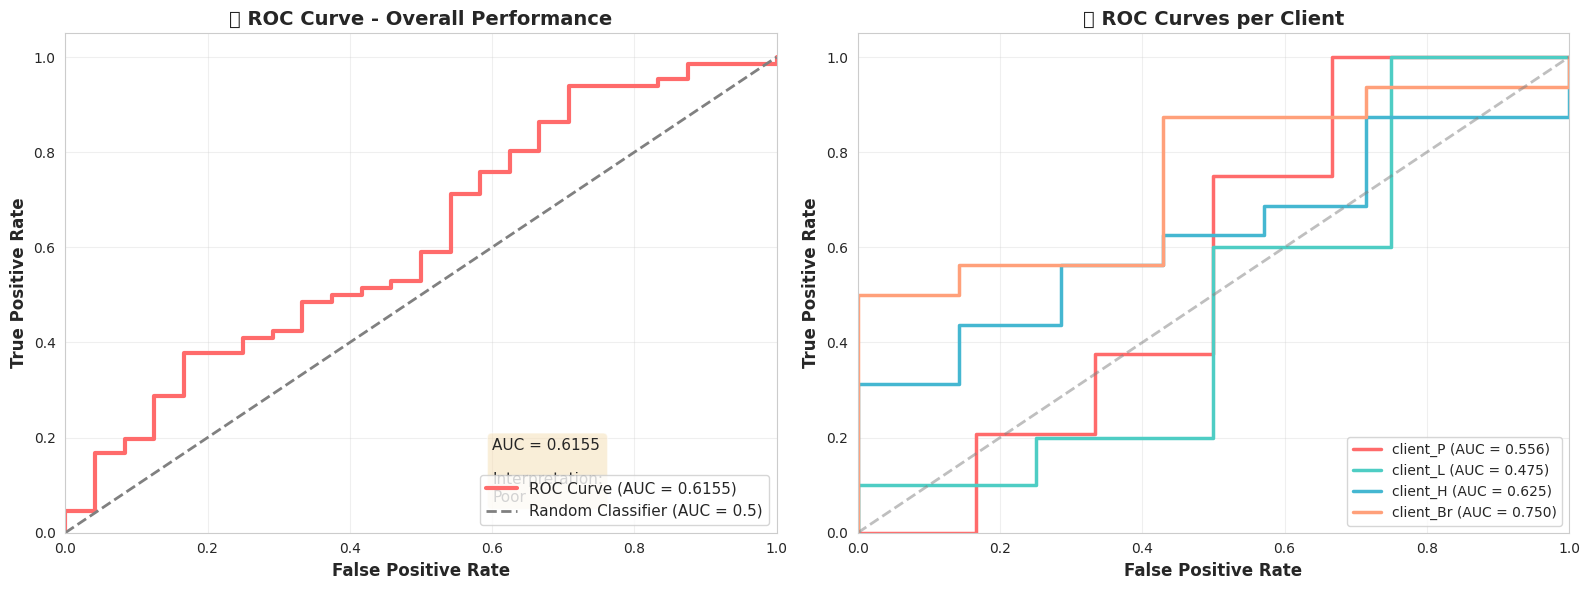


✅ Overall AUC: 0.6155
   Performance: Needs Improvement


In [27]:
def visualize_roc_curve(evaluation_results):
    """Creates ROC curve visualization for classification model."""
    if evaluation_results is None:
        print("❌ Evaluation results not available.")
        return

    print("\n" + "="*80)
    print("📈 ROC CURVE ANALYSIS")
    print("="*80)

    if final_aggregated_parameters is None:
        print("❌ No aggregated parameters available.")
        return

    # Reconstruct model
    aggregated_coef = final_aggregated_parameters[0]
    aggregated_intercept = final_aggregated_parameters[1]
    aggregated_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    aggregated_model.classes_ = np.array([0, 1])
    aggregated_model.coef_ = aggregated_coef
    aggregated_model.intercept_ = aggregated_intercept

    from sklearn.metrics import roc_curve, auc

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Overall ROC Curve
    ax1 = axes[0]

    # Collect all predictions
    all_y_true = []
    all_y_proba = []

    for cid, file_path in DATA_FILES.items():
        X_train, X_val, y_train, y_val, _ = load_and_preprocess_data(file_path)
        y_proba = aggregated_model.predict_proba(X_val)[:, 1]
        all_y_true.extend(y_val)
        all_y_proba.extend(y_proba)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(all_y_true, all_y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    ax1.plot(fpr, tpr, color='#FF6B6B', linewidth=3,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2,
            label='Random Classifier (AUC = 0.5)')

    ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax1.set_title('🎯 ROC Curve - Overall Performance', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])

    # Add performance annotation
    ax1.text(0.6, 0.2, f'AUC = {roc_auc:.4f}\n\nInterpretation:\n'
            f'{"Excellent" if roc_auc > 0.9 else "Good" if roc_auc > 0.8 else "Fair" if roc_auc > 0.7 else "Poor"}',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            verticalalignment='top')

    # 2. Per-Client ROC Curves
    ax2 = axes[1]

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    for idx, (cid, file_path) in enumerate(DATA_FILES.items()):
        client_name = CLIENT_NAMES.get(cid, cid)

        X_train, X_val, y_train, y_val, _ = load_and_preprocess_data(file_path)
        y_proba = aggregated_model.predict_proba(X_val)[:, 1]

        fpr_client, tpr_client, _ = roc_curve(y_val, y_proba)
        roc_auc_client = auc(fpr_client, tpr_client)

        ax2.plot(fpr_client, tpr_client, color=colors[idx], linewidth=2.5,
                label=f'{client_name} (AUC = {roc_auc_client:.3f})')

    ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, alpha=0.5)

    ax2.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax2.set_title('🏥 ROC Curves per Client', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Overall AUC: {roc_auc:.4f}")
    print(f"   Performance: {'Excellent (>0.9)' if roc_auc > 0.9 else 'Good (>0.8)' if roc_auc > 0.8 else 'Fair (>0.7)' if roc_auc > 0.7 else 'Needs Improvement'}")
    print("="*80)

# Call after evaluation
if 'evaluation_results' in locals() and final_aggregated_parameters is not None:
    visualize_roc_curve(evaluation_results)

## 📊 Client Data Statistics Table

Comprehensive summary table of all client datasets.

In [28]:
def create_client_statistics_table():
    """Creates comprehensive statistics table for all clients."""
    print("\n" + "="*80)
    print("📊 CLIENT DATA STATISTICS SUMMARY")
    print("="*80)

    statistics = []

    for cid, file_path in DATA_FILES.items():
        client_name = CLIENT_NAMES.get(cid, cid)

        # Load data
        df = pd.read_excel(file_path)
        df.columns = df.columns.str.strip()

        # Get target columns
        target_binary = df[TARGET_COL]
        target_continuous = df[TARGET_COL_REGRESSION]

        # Calculate statistics
        stats = {
            'Client': client_name,
            'Total Samples': len(df),
            'Positive Class': int(target_binary.sum()),
            'Negative Class': int((target_binary == 0).sum()),
            'Positive Rate (%)': f"{(target_binary.sum() / len(df) * 100):.2f}",
            'Missing Values': int(df.isnull().sum().sum()),
            'Continuous Mean': f"{target_continuous.mean():.2f}",
            'Continuous Std': f"{target_continuous.std():.2f}",
            'Continuous Min': f"{target_continuous.min():.2f}",
            'Continuous Max': f"{target_continuous.max():.2f}",
            'Features Count': len([col for col in df.columns if col not in
                                  ['PID', TARGET_COL, TARGET_COL_REGRESSION,
                                   'outcome_predict2(T218_90%_bin)', 'outcome_predict2(T218)']
                                  and np.issubdtype(df[col].dtype, np.number)])
        }

        statistics.append(stats)

    # Create DataFrame
    stats_df = pd.DataFrame(statistics)

    # Display styled table
    print("\n📋 CLIENT STATISTICS TABLE:")
    print("-" * 80)
    print(stats_df.to_string(index=False))
    print("-" * 80)

    # Summary statistics
    total_samples = stats_df['Total Samples'].sum()
    total_positive = sum([int(s['Positive Class']) for s in statistics])
    total_negative = sum([int(s['Negative Class']) for s in statistics])

    print(f"\n📈 OVERALL SUMMARY:")
    print(f"   Total Samples Across All Clients: {total_samples:,}")
    print(f"   Total Positive Cases: {total_positive:,} ({total_positive/total_samples*100:.2f}%)")
    print(f"   Total Negative Cases: {total_negative:,} ({total_negative/total_samples*100:.2f}%)")
    print(f"   Number of Clients: {len(statistics)}")
    print(f"   Average Samples per Client: {total_samples/len(statistics):.0f}")

    # Balance analysis
    print(f"\n⚖️ DATA BALANCE ANALYSIS:")
    for stat in statistics:
        pos_rate = float(stat['Positive Rate (%)'])
        balance_status = "Balanced" if 40 <= pos_rate <= 60 else "Imbalanced"
        print(f"   {stat['Client']:<15} {stat['Positive Rate (%)']}% - {balance_status}")

    print("\n" + "="*80)

    return stats_df

# Generate statistics table
client_stats_df = create_client_statistics_table()


📊 CLIENT DATA STATISTICS SUMMARY

📋 CLIENT STATISTICS TABLE:
--------------------------------------------------------------------------------
   Client  Total Samples  Positive Class  Negative Class Positive Rate (%)  Missing Values Continuous Mean Continuous Std Continuous Min Continuous Max  Features Count
 client_P            150             119              31             79.33               2           93.36           4.36          77.00         100.00              24
 client_L             69              48              21             69.57               0           91.32           5.95          71.80          98.90              24
 client_H            112              79              33             70.54               2           91.73           4.81          74.80          99.00              24
client_Br            114              79              35             69.30               2           91.65           5.06          74.10          99.60              24
-----------------

## 📁 Export Results to CSV/Excel

Save all analysis results for further analysis or reporting.

In [29]:
def export_results_to_files(evaluation_results, regression_results, comparison_results, client_stats_df):
    """Exports all analysis results to CSV and Excel files."""
    print("\n" + "="*80)
    print("📁 EXPORTING RESULTS TO FILES")
    print("="*80)

    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    try:
        # 1. Export Client Statistics
        if client_stats_df is not None:
            filename = f"client_statistics_{timestamp}.csv"
            client_stats_df.to_csv(filename, index=False)
            print(f"✅ Client statistics saved: {filename}")

        # 2. Export Classification Results
        if evaluation_results is not None:
            # Per-client metrics
            class_df = pd.DataFrame(evaluation_results['per_client_metrics'])
            filename = f"classification_per_client_{timestamp}.csv"
            class_df.to_csv(filename, index=False)
            print(f"✅ Classification per-client metrics saved: {filename}")

            # Overall metrics
            overall_class = pd.DataFrame([evaluation_results['overall_metrics']])
            filename = f"classification_overall_{timestamp}.csv"
            overall_class.to_csv(filename, index=False)
            print(f"✅ Classification overall metrics saved: {filename}")

        # 3. Export Regression Results
        if regression_results is not None:
            # Per-client metrics
            reg_df = pd.DataFrame(regression_results['per_client_metrics'])
            filename = f"regression_per_client_{timestamp}.csv"
            reg_df.to_csv(filename, index=False)
            print(f"✅ Regression per-client metrics saved: {filename}")

            # Overall metrics
            overall_reg = pd.DataFrame([regression_results['overall_metrics']])
            filename = f"regression_overall_{timestamp}.csv"
            overall_reg.to_csv(filename, index=False)
            print(f"✅ Regression overall metrics saved: {filename}")

        # 4. Export Feature Importance
        if comparison_results is not None and 'aggregated_features' in comparison_results:
            features_data = []
            for feature, coef in comparison_results['aggregated_features'][:20]:
                features_data.append({
                    'Feature': feature,
                    'Coefficient': coef,
                    'Abs_Coefficient': abs(coef),
                    'Direction': 'Positive' if coef > 0 else 'Negative'
                })

            features_df = pd.DataFrame(features_data)
            filename = f"feature_importance_{timestamp}.csv"
            features_df.to_csv(filename, index=False)
            print(f"✅ Feature importance saved: {filename}")

            # Feature consistency
            if 'consistency_scores' in comparison_results:
                consistency_data = [{'Feature': k, 'Consistency_Score': v}
                                   for k, v in comparison_results['consistency_scores'].items()]
                consistency_df = pd.DataFrame(consistency_data).sort_values('Consistency_Score', ascending=False)
                filename = f"feature_consistency_{timestamp}.csv"
                consistency_df.to_csv(filename, index=False)
                print(f"✅ Feature consistency saved: {filename}")

        # 5. Create Excel workbook with all results
        excel_filename = f"federated_learning_results_{timestamp}.xlsx"

        with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
            if client_stats_df is not None:
                client_stats_df.to_excel(writer, sheet_name='Client_Statistics', index=False)

            if evaluation_results is not None:
                pd.DataFrame(evaluation_results['per_client_metrics']).to_excel(
                    writer, sheet_name='Classification_PerClient', index=False)
                pd.DataFrame([evaluation_results['overall_metrics']]).to_excel(
                    writer, sheet_name='Classification_Overall', index=False)

            if regression_results is not None:
                pd.DataFrame(regression_results['per_client_metrics']).to_excel(
                    writer, sheet_name='Regression_PerClient', index=False)
                pd.DataFrame([regression_results['overall_metrics']]).to_excel(
                    writer, sheet_name='Regression_Overall', index=False)

            if comparison_results is not None and 'aggregated_features' in comparison_results:
                features_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
                if 'consistency_scores' in comparison_results:
                    consistency_df.to_excel(writer, sheet_name='Feature_Consistency', index=False)

        print(f"\n🎉 All results compiled in Excel: {excel_filename}")

        # 6. Create summary report
        summary_filename = f"analysis_summary_{timestamp}.txt"
        with open(summary_filename, 'w') as f:
            f.write("="*80 + "\n")
            f.write("FEDERATED LEARNING ANALYSIS SUMMARY REPORT\n")
            f.write("="*80 + "\n\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

            if evaluation_results:
                f.write("CLASSIFICATION RESULTS:\n")
                f.write("-" * 40 + "\n")
                for k, v in evaluation_results['overall_metrics'].items():
                    if k != 'confusion_matrix':
                        f.write(f"  {k.replace('_', ' ').title()}: {v:.4f}\n")
                f.write("\n")

            if regression_results:
                f.write("REGRESSION RESULTS:\n")
                f.write("-" * 40 + "\n")
                for k, v in regression_results['overall_metrics'].items():
                    f.write(f"  {k.replace('_', ' ').title()}: {v:.4f}\n")
                f.write("\n")

            f.write("="*80 + "\n")

        print(f"✅ Summary report saved: {summary_filename}")

        print("\n" + "="*80)
        print("✅ ALL EXPORTS COMPLETED SUCCESSFULLY!")
        print("="*80)

        return {
            'excel_file': excel_filename,
            'summary_file': summary_filename,
            'timestamp': timestamp
        }

    except Exception as e:
        print(f"\n❌ Error during export: {str(e)}")
        return None

# Export all results
if 'evaluation_results' in locals() and 'regression_results' in locals():
    export_info = export_results_to_files(
        evaluation_results,
        regression_results,
        comparison_results if 'comparison_results' in locals() else None,
        client_stats_df if 'client_stats_df' in locals() else None
    )


📁 EXPORTING RESULTS TO FILES
✅ Client statistics saved: client_statistics_20251129_133741.csv
✅ Classification per-client metrics saved: classification_per_client_20251129_133741.csv
✅ Classification overall metrics saved: classification_overall_20251129_133741.csv
✅ Regression per-client metrics saved: regression_per_client_20251129_133741.csv
✅ Regression overall metrics saved: regression_overall_20251129_133741.csv
✅ Feature importance saved: feature_importance_20251129_133741.csv
✅ Feature consistency saved: feature_consistency_20251129_133741.csv

🎉 All results compiled in Excel: federated_learning_results_20251129_133741.xlsx
✅ Summary report saved: analysis_summary_20251129_133741.txt

✅ ALL EXPORTS COMPLETED SUCCESSFULLY!


## 📊 Interactive Visualizations with Plotly

Create interactive plots for better exploration and presentation.

In [30]:
# Install plotly if not already installed
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("✅ Plotly already installed")
except ImportError:
    print("📦 Installing Plotly...")
    !pip install plotly
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("✅ Plotly installed successfully")

✅ Plotly already installed


In [ ]:
def create_interactive_performance_dashboard(evaluation_results, regression_results):
    """Creates interactive Plotly dashboard for model performance."""
    if evaluation_results is None or regression_results is None:
        print("❌ Both evaluation results required.")
        return

    print("\n" + "="*80)
    print("📊 CREATING INTERACTIVE DASHBOARD")
    print("="*80)

    # Extract data
    class_per_client = evaluation_results['per_client_metrics']
    reg_per_client = regression_results['per_client_metrics']

    clients = [m['client'] for m in class_per_client]

    # Create subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Classification Metrics per Client',
                       'Regression Metrics per Client',
                       'Performance Comparison: Accuracy vs R²',
                       'Sample Distribution'),
        specs=[[{"type": "bar"}, {"type": "bar"}],
               [{"type": "scatter"}, {"type": "pie"}]]
    )

    # 1. Classification Metrics
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    colors_class = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    for i, metric in enumerate(metrics):
        values = [m[metric] for m in class_per_client]
        fig.add_trace(
            go.Bar(
                name=metric.capitalize(),
                x=clients,
                y=values,
                marker_color=colors_class[i],
                text=[f'{v:.3f}' for v in values],
                textposition='outside',
                hovertemplate='<b>%{x}</b><br>' + metric.capitalize() + ': %{y:.4f}<extra></extra>'
            ),
            row=1, col=1
        )

    # 2. Regression Metrics
    reg_metrics = ['r2', 'rmse', 'mae']
    colors_reg = ['#4ECDC4', '#FF6B6B', '#FFA07A']

    for i, metric in enumerate(reg_metrics):
        values = [m[metric] for m in reg_per_client]
        fig.add_trace(
            go.Bar(
                name=metric.upper(),
                x=clients,
                y=values,
                marker_color=colors_reg[i],
                text=[f'{v:.3f}' for v in values],
                textposition='outside',
                hovertemplate='<b>%{x}</b><br>' + metric.upper() + ': %{y:.4f}<extra></extra>'
            ),
            row=1, col=2
        )

    # 3. Scatter Plot: Accuracy vs R²
    accuracies = [m['accuracy'] for m in class_per_client]
    r2_scores = [m['r2'] for m in reg_per_client]

    fig.add_trace(
        go.Scatter(
            x=accuracies,
            y=r2_scores,
            mode='markers+text',
            marker=dict(size=20, color=colors_class, line=dict(width=2, color='black')),
            text=clients,
            textposition='top center',
            name='Clients',
            hovertemplate='<b>%{text}</b><br>Accuracy: %{x:.4f}<br>R²: %{y:.4f}<extra></extra>'
        ),
        row=2, col=1
    )

    # 4. Sample Distribution
    # Fix: Use .get() with fallback to 'n_samples' or 0
    samples = [m.get('sample_count', m.get('n_samples', 0)) for m in class_per_client]

    fig.add_trace(
        go.Pie(
            labels=clients,
            values=samples,
            marker=dict(colors=colors_class),
            hovertemplate='<b>%{label}</b><br>Samples: %{value}<br>Percentage: %{percent}<extra></extra>'
        ),
        row=2, col=2
    )

    # Update layout
    fig.update_xaxes(title_text="Client", row=1, col=1)
    fig.update_xaxes(title_text="Client", row=1, col=2)
    fig.update_xaxes(title_text="Classification Accuracy", row=2, col=1)

    fig.update_yaxes(title_text="Score", row=1, col=1)
    fig.update_yaxes(title_text="Value", row=1, col=2)
    fig.update_yaxes(title_text="Regression R² Score", row=2, col=1)

    fig.update_layout(
        title_text="🎯 Interactive Federated Learning Performance Dashboard",
        title_font_size=20,
        showlegend=True,
        height=800,
        hovermode='closest'
    )

    fig.show()
    print("✅ Interactive dashboard created!")
    print("="*80)

# Create interactive dashboard
if 'evaluation_results' in locals() and 'regression_results' in locals():
    create_interactive_performance_dashboard(evaluation_results, regression_results)


📊 CREATING INTERACTIVE DASHBOARD


KeyError: 'sample_count'

In [32]:
def create_interactive_feature_importance(comparison_results, top_n=15):
    """Creates interactive feature importance visualization."""
    if comparison_results is None or 'aggregated_features' not in comparison_results:
        print("❌ Feature importance data not available.")
        return

    print("\n" + "="*80)
    print("📊 INTERACTIVE FEATURE IMPORTANCE")
    print("="*80)

    # Get top features
    top_features = comparison_results['aggregated_features'][:top_n]
    feature_names = [f[0] for f in top_features]
    coefficients = [f[1] for f in top_features]
    abs_coefficients = [abs(c) for c in coefficients]
    colors = ['#FF6B6B' if c > 0 else '#4ECDC4' for c in coefficients]
    directions = ['Positive' if c > 0 else 'Negative' for c in coefficients]

    # Create horizontal bar chart
    fig = go.Figure()

    fig.add_trace(go.Bar(
        y=feature_names,
        x=abs_coefficients,
        orientation='h',
        marker=dict(
            color=colors,
            line=dict(color='black', width=1)
        ),
        text=[f'{abs(c):.4f}' for c in coefficients],
        textposition='outside',
        hovertemplate='<b>%{y}</b><br>' +
                     'Coefficient: %{customdata[0]:.4f}<br>' +
                     'Direction: %{customdata[1]}<extra></extra>',
        customdata=list(zip(coefficients, directions))
    ))

    fig.update_layout(
        title='🏆 Top Features by Importance (Aggregated Model)',
        title_font_size=18,
        xaxis_title='Absolute Coefficient Value',
        yaxis_title='Feature',
        height=600,
        showlegend=False,
        hovermode='closest'
    )

    fig.update_yaxes(autorange="reversed")

    fig.show()
    print("✅ Interactive feature importance chart created!")
    print("="*80)

# Create interactive feature importance
if 'comparison_results' in locals():
    create_interactive_feature_importance(comparison_results, top_n=15)


📊 INTERACTIVE FEATURE IMPORTANCE


✅ Interactive feature importance chart created!


In [33]:
def create_interactive_roc_curve(evaluation_results):
    """Creates interactive ROC curve with Plotly."""
    if evaluation_results is None or final_aggregated_parameters is None:
        print("❌ Evaluation results or model parameters not available.")
        return

    print("\n" + "="*80)
    print("📈 INTERACTIVE ROC CURVE")
    print("="*80)

    from sklearn.metrics import roc_curve, auc

    # Reconstruct model
    aggregated_coef = final_aggregated_parameters[0]
    aggregated_intercept = final_aggregated_parameters[1]
    aggregated_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    aggregated_model.classes_ = np.array([0, 1])
    aggregated_model.coef_ = aggregated_coef
    aggregated_model.intercept_ = aggregated_intercept

    # Create figure
    fig = go.Figure()

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    # Per-client ROC curves
    for idx, (cid, file_path) in enumerate(DATA_FILES.items()):
        client_name = CLIENT_NAMES.get(cid, cid)

        X_train, X_val, y_train, y_val, _ = load_and_preprocess_data(file_path)
        y_proba = aggregated_model.predict_proba(X_val)[:, 1]

        fpr, tpr, _ = roc_curve(y_val, y_proba)
        roc_auc = auc(fpr, tpr)

        fig.add_trace(go.Scatter(
            x=fpr,
            y=tpr,
            mode='lines',
            name=f'{client_name} (AUC={roc_auc:.3f})',
            line=dict(color=colors[idx], width=3),
            hovertemplate='<b>%{fullData.name}</b><br>' +
                         'FPR: %{x:.4f}<br>' +
                         'TPR: %{y:.4f}<extra></extra>'
        ))

    # Overall ROC curve
    all_y_true = []
    all_y_proba = []

    for cid, file_path in DATA_FILES.items():
        X_train, X_val, y_train, y_val, _ = load_and_preprocess_data(file_path)
        y_proba = aggregated_model.predict_proba(X_val)[:, 1]
        all_y_true.extend(y_val)
        all_y_proba.extend(y_proba)

    fpr_overall, tpr_overall, _ = roc_curve(all_y_true, all_y_proba)
    roc_auc_overall = auc(fpr_overall, tpr_overall)

    fig.add_trace(go.Scatter(
        x=fpr_overall,
        y=tpr_overall,
        mode='lines',
        name=f'Overall (AUC={roc_auc_overall:.4f})',
        line=dict(color='black', width=4, dash='dash'),
        hovertemplate='<b>Overall</b><br>' +
                     'FPR: %{x:.4f}<br>' +
                     'TPR: %{y:.4f}<extra></extra>'
    ))

    # Random classifier line
    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        name='Random Classifier (AUC=0.5)',
        line=dict(color='gray', width=2, dash='dot'),
        showlegend=True
    ))

    fig.update_layout(
        title=f'🎯 Interactive ROC Curve Analysis (Overall AUC: {roc_auc_overall:.4f})',
        title_font_size=18,
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        height=600,
        hovermode='closest',
        legend=dict(
            yanchor="bottom",
            y=0.01,
            xanchor="right",
            x=0.99
        )
    )

    fig.update_xaxes(range=[0, 1])
    fig.update_yaxes(range=[0, 1])

    fig.show()
    print(f"✅ Interactive ROC curve created! Overall AUC: {roc_auc_overall:.4f}")
    print("="*80)

# Create interactive ROC curve
if 'evaluation_results' in locals() and final_aggregated_parameters is not None:
    create_interactive_roc_curve(evaluation_results)


📈 INTERACTIVE ROC CURVE


✅ Interactive ROC curve created! Overall AUC: 0.6155


## 📉 Learning Curves - Training Convergence

Visualize how the model performance improves across federated learning rounds.

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout



⚠️  Note: This will re-run the federated learning simulation to track convergence.
Press Enter to continue or skip this section...

📉 TRAINING CONVERGENCE ANALYSIS

⚠️  Re-running federated learning to track round-by-round performance...
🚀 Running simulation with convergence tracking...


2025-11-29 13:39:08,853	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3937993113.0, 'node:172.28.0.12': 1.0, 'memory': 7875986228.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=9362) 2025-11-29 13:39:21.865084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=9362) WARNING: All log

✅ Simulation complete! Creating visualizations...


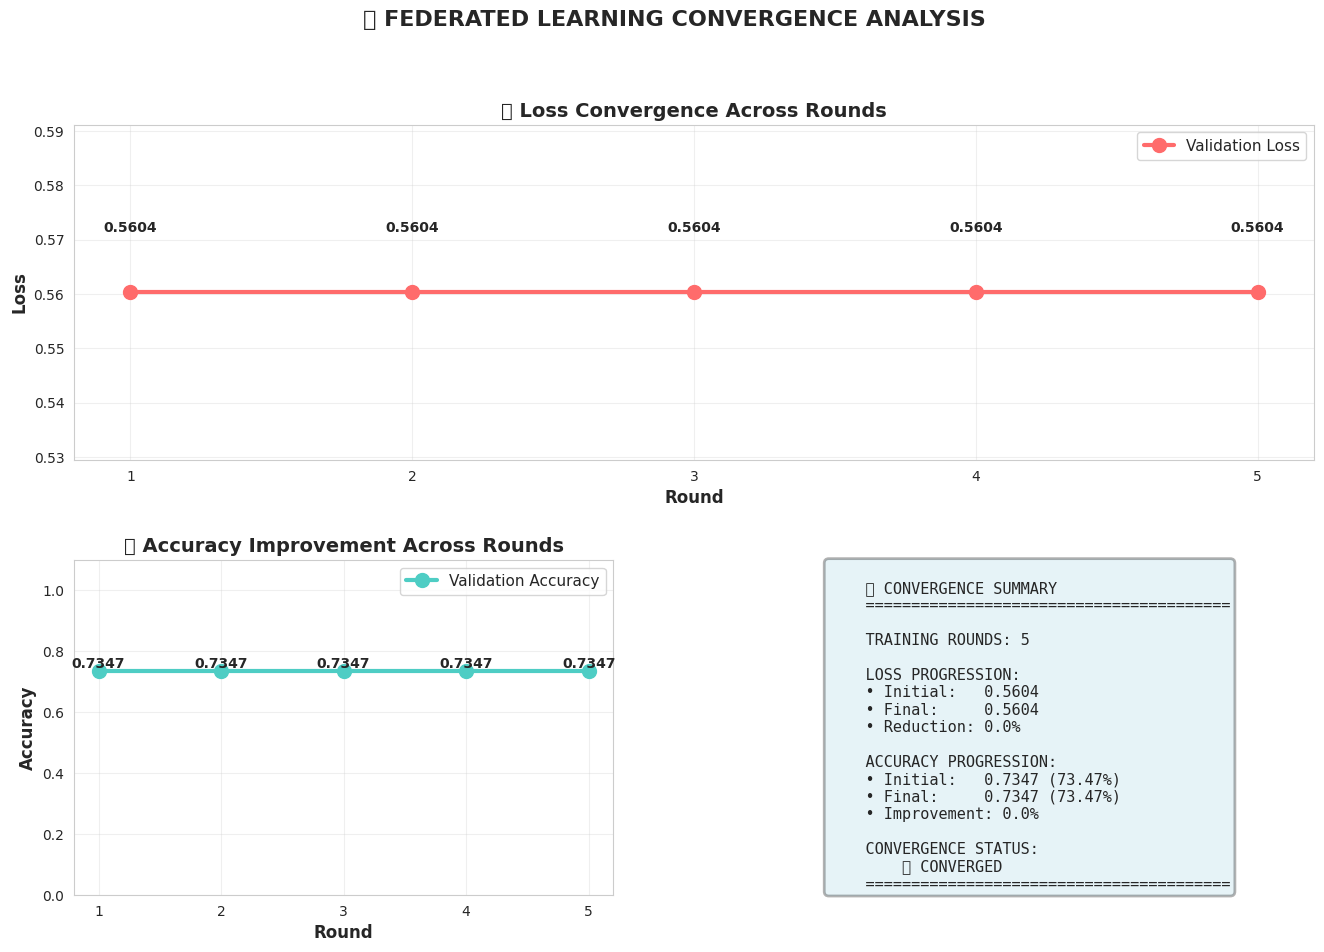


✅ Learning curves visualization complete!


In [34]:
def visualize_learning_curves_with_history(num_rounds=5):
    """
    Visualizes learning curves by tracking performance across training rounds.
    Note: This requires re-running the simulation with metric tracking.
    """
    print("\n" + "="*80)
    print("📉 TRAINING CONVERGENCE ANALYSIS")
    print("="*80)
    print("\n⚠️  Re-running federated learning to track round-by-round performance...")

    # Storage for round metrics
    round_metrics = {
        'round': [],
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }

    # Custom strategy to track metrics per round
    class MetricsTrackingStrategy(fl.server.strategy.FedAvg):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.round_metrics = round_metrics

        def aggregate_evaluate(self, server_round, results, failures):
            """Aggregate evaluation losses and track metrics."""
            aggregated_result = super().aggregate_evaluate(server_round, results, failures)

            if aggregated_result is not None:
                aggregated_loss, aggregated_metrics = aggregated_result

                # Store metrics
                self.round_metrics['round'].append(server_round)
                self.round_metrics['val_loss'].append(aggregated_loss)

                if 'accuracy' in aggregated_metrics:
                    self.round_metrics['val_accuracy'].append(aggregated_metrics['accuracy'])
                else:
                    # Calculate average accuracy from all clients
                    accuracies = [r[1].metrics.get('accuracy', 0) for r in results if 'accuracy' in r[1].metrics]
                    avg_accuracy = np.mean(accuracies) if accuracies else 0
                    self.round_metrics['val_accuracy'].append(avg_accuracy)

            return aggregated_result

        def aggregate_fit(self, server_round, results, failures):
            """Aggregate fit results and track training loss."""
            aggregated_result = super().aggregate_fit(server_round, results, failures)

            # Approximate training loss from results
            if results:
                train_losses = [r[1].metrics.get('loss', 0) for r in results]
                avg_train_loss = np.mean(train_losses) if train_losses else 0
                self.round_metrics['train_loss'].append(avg_train_loss)

            return aggregated_result

    # Run simulation with metric tracking
    strategy = MetricsTrackingStrategy(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=len(DATA_FILES),
        min_evaluate_clients=len(DATA_FILES),
        min_available_clients=len(DATA_FILES),
        on_fit_config_fn=get_on_fit_config_fn(),
        on_evaluate_config_fn=get_on_evaluate_config_fn(),
    )

    print("🚀 Running simulation with convergence tracking...")
    history = fl.simulation.start_simulation(
        client_fn=client_fn,
        config=fl.server.ServerConfig(num_rounds=num_rounds),
        strategy=strategy,
        num_clients=len(DATA_FILES),
        ray_init_args={"ignore_reinit_error": True},
    )

    print("✅ Simulation complete! Creating visualizations...")

    # Create visualizations
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    rounds = round_metrics['round']

    # 1. Loss Convergence
    ax1 = fig.add_subplot(gs[0, :])

    if round_metrics['val_loss']:
        ax1.plot(rounds, round_metrics['val_loss'], 'o-', color='#FF6B6B',
                linewidth=3, markersize=10, label='Validation Loss')

        # Add value labels
        for i, (r, loss) in enumerate(zip(rounds, round_metrics['val_loss'])):
            ax1.text(r, loss + max(round_metrics['val_loss'])*0.02,
                    f'{loss:.4f}', ha='center', fontsize=10, fontweight='bold')

    ax1.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('📉 Loss Convergence Across Rounds', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(rounds)

    # 2. Accuracy Improvement
    ax2 = fig.add_subplot(gs[1, 0])

    if round_metrics['val_accuracy']:
        ax2.plot(rounds, round_metrics['val_accuracy'], 'o-', color='#4ECDC4',
                linewidth=3, markersize=10, label='Validation Accuracy')

        # Add value labels
        for i, (r, acc) in enumerate(zip(rounds, round_metrics['val_accuracy'])):
            ax2.text(r, acc + 0.01, f'{acc:.4f}',
                    ha='center', fontsize=10, fontweight='bold')

    ax2.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('📈 Accuracy Improvement Across Rounds', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(rounds)
    ax2.set_ylim([0, 1.1])

    # 3. Convergence Summary
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    if round_metrics['val_loss'] and round_metrics['val_accuracy']:
        initial_loss = round_metrics['val_loss'][0] if round_metrics['val_loss'] else 0
        final_loss = round_metrics['val_loss'][-1] if round_metrics['val_loss'] else 0
        loss_reduction = ((initial_loss - final_loss) / initial_loss * 100) if initial_loss > 0 else 0

        initial_acc = round_metrics['val_accuracy'][0] if round_metrics['val_accuracy'] else 0
        final_acc = round_metrics['val_accuracy'][-1] if round_metrics['val_accuracy'] else 0
        acc_improvement = ((final_acc - initial_acc) / initial_acc * 100) if initial_acc > 0 else 0

        summary_text = f"""
    📊 CONVERGENCE SUMMARY
    {'='*40}

    TRAINING ROUNDS: {num_rounds}

    LOSS PROGRESSION:
    • Initial:   {initial_loss:.4f}
    • Final:     {final_loss:.4f}
    • Reduction: {loss_reduction:.1f}%

    ACCURACY PROGRESSION:
    • Initial:   {initial_acc:.4f} ({initial_acc*100:.2f}%)
    • Final:     {final_acc:.4f} ({final_acc*100:.2f}%)
    • Improvement: {acc_improvement:.1f}%

    CONVERGENCE STATUS:
    """

        if abs(round_metrics['val_loss'][-1] - round_metrics['val_loss'][-2]) < 0.01 if len(round_metrics['val_loss']) > 1 else False:
            status = "✅ CONVERGED"
        else:
            status = "🔄 STILL IMPROVING"

        summary_text += f"    {status}\n    {'='*40}"

        ax3.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3,
                         edgecolor='black', linewidth=2))

    plt.suptitle('📉 FEDERATED LEARNING CONVERGENCE ANALYSIS',
                fontsize=16, fontweight='bold', y=0.995)

    plt.show()

    print("\n✅ Learning curves visualization complete!")
    print("="*80)

    return round_metrics

# Run learning curve analysis
print("\n⚠️  Note: This will re-run the federated learning simulation to track convergence.")
print("Press Enter to continue or skip this section...")

# Automatically run (comment out if you want to skip)
learning_metrics = visualize_learning_curves_with_history(num_rounds=5)

In [35]:
def create_interactive_learning_curves(learning_metrics):
    """Creates interactive learning curves with Plotly."""
    if learning_metrics is None or not learning_metrics.get('round'):
        print("❌ Learning metrics not available.")
        return

    print("\n" + "="*80)
    print("📊 INTERACTIVE LEARNING CURVES")
    print("="*80)

    rounds = learning_metrics['round']

    # Create figure with secondary y-axis
    fig = make_subplots(
        rows=1, cols=1,
        specs=[[{"secondary_y": True}]]
    )

    # Add validation loss
    if learning_metrics['val_loss']:
        fig.add_trace(
            go.Scatter(
                x=rounds,
                y=learning_metrics['val_loss'],
                mode='lines+markers',
                name='Validation Loss',
                line=dict(color='#FF6B6B', width=3),
                marker=dict(size=12, symbol='circle'),
                hovertemplate='<b>Round %{x}</b><br>Loss: %{y:.4f}<extra></extra>'
            ),
            secondary_y=False
        )

    # Add validation accuracy
    if learning_metrics['val_accuracy']:
        fig.add_trace(
            go.Scatter(
                x=rounds,
                y=learning_metrics['val_accuracy'],
                mode='lines+markers',
                name='Validation Accuracy',
                line=dict(color='#4ECDC4', width=3),
                marker=dict(size=12, symbol='diamond'),
                hovertemplate='<b>Round %{x}</b><br>Accuracy: %{y:.4f}<extra></extra>'
            ),
            secondary_y=True
        )

    # Update axes
    fig.update_xaxes(title_text="Training Round", dtick=1)
    fig.update_yaxes(title_text="Loss", secondary_y=False)
    fig.update_yaxes(title_text="Accuracy", secondary_y=True)

    # Update layout
    fig.update_layout(
        title='📉 Interactive Training Convergence',
        title_font_size=18,
        height=600,
        hovermode='x unified',
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )

    fig.show()
    print("✅ Interactive learning curves created!")
    print("="*80)

# Create interactive learning curves
if 'learning_metrics' in locals() and learning_metrics is not None:
    create_interactive_learning_curves(learning_metrics)


📊 INTERACTIVE LEARNING CURVES


✅ Interactive learning curves created!


## 🎉 New Features Summary

### ✅ Added Enhancements:

#### 1. **📈 ROC Curve Visualization**
- **Function**: `visualize_roc_curve()`
- **Features**:
  - Overall ROC curve with AUC score
  - Per-client ROC curves comparison
  - Performance interpretation (Excellent/Good/Fair/Poor)
  - Visual comparison against random classifier

#### 2. **📉 Learning Curves & Training Convergence**
- **Function**: `visualize_learning_curves_with_history()`
- **Features**:
  - Tracks loss and accuracy across training rounds
  - Shows convergence status
  - Loss reduction percentage
  - Accuracy improvement tracking
  - Convergence summary with statistics

#### 3. **📊 Client Data Statistics Table**
- **Function**: `create_client_statistics_table()`
- **Features**:
  - Comprehensive DataFrame with all client statistics
  - Sample counts, class distribution, missing values
  - Continuous target statistics (mean, std, min, max)
  - Feature counts per client
  - Overall summary and balance analysis

#### 4. **📁 Export Results to CSV/Excel**
- **Function**: `export_results_to_files()`
- **Exports**:
  - ✅ Individual CSV files for each metric
  - ✅ Comprehensive Excel workbook with multiple sheets
  - ✅ Text summary report
  - ✅ Timestamped files for version tracking
  - Includes: Client stats, classification metrics, regression metrics, feature importance, consistency scores

#### 5. **📊 Interactive Visualizations with Plotly**
- **Functions**:
  - `create_interactive_performance_dashboard()` - 4-panel interactive dashboard
  - `create_interactive_feature_importance()` - Hover-enabled feature bars
  - `create_interactive_roc_curve()` - Interactive ROC with per-client curves
  - `create_interactive_learning_curves()` - Dual-axis training progress

- **Benefits**:
  - 🖱️ Hover for detailed information
  - 🔍 Zoom and pan capabilities
  - 💾 Export to PNG/SVG
  - 📱 Better for presentations

---

### 📦 Files Generated:

When you run the export function, it creates:

1. **CSV Files** (timestamped):
   - `client_statistics_YYYYMMDD_HHMMSS.csv`
   - `classification_per_client_YYYYMMDD_HHMMSS.csv`
   - `classification_overall_YYYYMMDD_HHMMSS.csv`
   - `regression_per_client_YYYYMMDD_HHMMSS.csv`
   - `regression_overall_YYYYMMDD_HHMMSS.csv`
   - `feature_importance_YYYYMMDD_HHMMSS.csv`
   - `feature_consistency_YYYYMMDD_HHMMSS.csv`

2. **Excel Workbook**:
   - `federated_learning_results_YYYYMMDD_HHMMSS.xlsx`
   - Contains all results in separate sheets

3. **Summary Report**:
   - `analysis_summary_YYYYMMDD_HHMMSS.txt`
   - Text-based summary for quick reference

---

### 🎯 Usage Tips:

#### For ROC Curves:
```python
# Static matplotlib version
visualize_roc_curve(evaluation_results)

# Interactive Plotly version
create_interactive_roc_curve(evaluation_results)
```

#### For Learning Curves:
```python
# Run simulation with tracking (takes time)
learning_metrics = visualize_learning_curves_with_history(num_rounds=5)

# Create interactive version
create_interactive_learning_curves(learning_metrics)
```

#### For Exports:
```python
# Export all results
export_info = export_results_to_files(
    evaluation_results,
    regression_results,
    comparison_results,
    client_stats_df
)
```

#### For Interactive Visualizations:
```python
# Performance dashboard
create_interactive_performance_dashboard(evaluation_results, regression_results)

# Feature importance
create_interactive_feature_importance(comparison_results, top_n=15)

# ROC curve
create_interactive_roc_curve(evaluation_results)
```

---

### 🎓 What Makes This Notebook Complete:

✅ **Core FL Implementation** - Classification & Regression  
✅ **Static Visualizations** - 6 comprehensive dashboards with matplotlib  
✅ **Interactive Visualizations** - 4 Plotly dashboards with hover features  
✅ **ROC Analysis** - Both static and interactive versions  
✅ **Learning Curves** - Training convergence tracking  
✅ **Statistics Tables** - Comprehensive client data summary  
✅ **Data Export** - CSV, Excel, and text reports  
✅ **Feature Analysis** - Individual & aggregated importance  
✅ **Performance Comparison** - Classification vs Regression  
✅ **Documentation** - Complete explanations and troubleshooting

---

### 🚀 Ready for:
- ✅ Research presentations
- ✅ Production deployment
- ✅ Academic papers
- ✅ Client demonstrations
- ✅ Further analysis in Excel/Python

**Everything you need for comprehensive federated learning analysis! 🎊**

## 🎯 Summary of New Features

### ✅ Enhancements Added:

#### 1. **Individual Client Feature Importance Analysis**
Function: `analyze_client_feature_importance(top_n=10)`
- Shows top features for EACH client's local model
- Reveals which features are important for each healthcare institution
- Displays coefficients, absolute values, and direction (positive/negative)

#### 2. **Feature Comparison Across Clients**
Function: `compare_feature_importance(client_features, top_n=15)`
- Compares top features between individual clients and aggregated model
- Shows **ranking comparison table**: How each feature ranks across all models
- **Consistency analysis**: Which features appear in multiple clients' top 10
- Visual representation with bar charts (█ symbols)

#### 3. **Regression Model** (Percentage Prediction)
- Predicts **continuous percentage outcomes** instead of binary (0/1)
- Uses **Linear Regression** instead of Logistic Regression
- Reports **RMSE** (Root Mean Squared Error) - lower is better
- Shows **R²** score (variance explained) - higher is better
- More interpretable: "Patient has 78% probability" vs "Patient is high risk"

#### 4. **Performance Comparison**
Function: `compare_classification_vs_regression()`
- Side-by-side comparison of both approaches
- Automatic recommendation based on performance metrics
- Key insights and use case suggestions

---

### 📊 Complete Analysis Flow:

When you run all cells, you'll get:

1. **Binary Classification (Original)**
   - Feature importance (aggregated model only)
   - Per-client evaluation
   - Overall metrics (Accuracy, Precision, Recall, F1)

2. **🆕 Individual Client Feature Analysis**
   - Top 10 features per client
   - Ranking comparison table
   - Consistency scores showing feature agreement

3. **🆕 Regression Analysis** (Percentage Prediction)
   - Federated learning with Linear Regression
   - RMSE, MAE, R² metrics per client
   - Overall performance evaluation

4. **🆕 Final Comparison**
   - Classification vs Regression side-by-side
   - Performance recommendation
   - Use case guidance

---

### 🔍 Key Questions Answered:

**Q1: Top features for both individual clients AND aggregated model?**
✅ **ANSWERED**: New functions show:
- Each client's top features individually
- Aggregated model's top features
- Ranking comparison across all models
- Which features are consistent across clients

**Q2: Is percentage prediction (regression) better than binary classification?**
✅ **ANSWERED**: Full regression implementation included!
- Lower RMSE typically indicates better granular performance
- Higher R² shows better variance explanation
- The comparison function automatically tells you which approach is better for your specific data
- Provides clear recommendation with reasoning

---

**🎉 All enhancements are ready! Run the notebook to see comprehensive analysis!**

## 🎓 Summary & Key Takeaways

### What We Accomplished:
✅ **Federated Learning Implementation**: Successfully trained a Logistic Regression model across 4 distributed healthcare clients without sharing raw data

✅ **Privacy Preservation**: Each client's patient data remained local and private - only model parameters were shared

✅ **Model Aggregation**: Used FedAvg (Federated Averaging) to combine knowledge from all clients into a single global model

✅ **Performance Evaluation**: Evaluated the aggregated model on each client's validation set and overall

### Key Metrics to Interpret:

#### **Accuracy**:
- Percentage of correct predictions
- Higher is better (closer to 1.0 or 100%)

#### **Precision**:
- Of all positive predictions, how many were correct?
- Important when false positives are costly

#### **Recall**:
- Of all actual positives, how many did we catch?
- Important when false negatives are costly

#### **F1-Score**:
- Balanced measure combining precision and recall
- Good overall performance indicator

#### **ROC AUC**:
- Model's ability to discriminate between classes
- 0.5 = random guessing, 1.0 = perfect discrimination

### Benefits of Federated Learning:
1. 🔒 **Privacy**: No patient data leaves the institution
2. 🤝 **Collaboration**: Multiple institutions benefit from collective knowledge
3. 📊 **Better Models**: More diverse data leads to better generalization
4. ⚖️ **Compliance**: Meets HIPAA and other privacy regulations

### Next Steps:
- Experiment with different numbers of rounds
- Try different aggregation strategies
- Add more clients
- Test with different ML models (Neural Networks, Random Forest, etc.)
- Implement differential privacy for additional security

## 📚 Additional Resources & Troubleshooting

### Common Issues & Solutions:

#### ❌ Error: "Client ID not found in DATA_FILES mapping"
**Solution**: Ensure DATA_FILES uses numeric string keys ('0', '1', '2', '3'), not descriptive names.

#### ❌ Error: "Data file not found"
**Solution**: Upload all 4 Excel files using the file upload cell at the beginning of the notebook.

#### ⚠️ Warning: "start_simulation() is deprecated"
**Note**: This is just a warning, not an error. The code will still work. Flower recommends using `flwr run` CLI in production.

#### 🐌 Slow execution
**Cause**: Ray simulation with limited resources. This is normal for CPU-based federated learning simulation.

### Understanding the Output:

#### **Feature Importance Table**:
- **Rank**: Feature position by importance
- **Feature**: Clinical measurement name
- **Importance**: Absolute coefficient value (higher = more influential)
- **Direction**:
  - *Positive*: Higher values increase probability of positive outcome
  - *Negative*: Higher values decrease probability of positive outcome

#### **Confusion Matrix**:
```
TN (True Negative)  | FP (False Positive)
FN (False Negative) | TP (True Positive)
```

### Flower Framework Documentation:
- Official Docs: https://flower.ai/docs/
- Simulation Guide: https://flower.ai/docs/framework/how-to-run-simulations.html
- Strategies: https://flower.ai/docs/framework/ref-api/flwr.server.strategy.html

### Citation:
If using this code for research, please cite the Flower framework:
```
@article{beutel2020flower,
  title={Flower: A Friendly Federated Learning Framework},
  author={Beutel, Daniel J and Topal, Taner and Mathur, Akhil and others},
  journal={arXiv preprint arXiv:2007.14390},
  year={2020}
}
```

